<a href="https://colab.research.google.com/github/shatlykgurdov/jupyter_notebooks/blob/main/MScFE642_GWP1_Steps1_8_Combined.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MScFE 642 — Deep Learning for Finance
## Group Work Project 1 — Combined Notebook, Steps 1–8
**Student Group 17444**

This master notebook combines the group's work for **Steps 1 through 8** in chronological order.

- Steps 1–2: data, EDA, stationarity, and MLPs
- Step 3: CNN with Gramian Angular Field (GAF)
- Step 4: single-output LSTM
- Step 5: multi-output LSTM
- Step 6: asset-allocation strategy and backtest
- Step 7: group discussion across all results
- Step 8: reproducibility and submission checks

## 0. Common installation and imports

In [1]:
# Google Colab / Jupyter common environment for the full project
%pip -q install yfinance pyts statsmodels scikit-learn seaborn nbconvert

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 34.4 MB/s eta 0:00:00


In [2]:
import os
import json
import random
import warnings
import zipfile
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf

from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from pyts.image import GramianAngularField

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input, Dense, Dropout, LSTM, Conv2D, MaxPooling2D, Flatten
)
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Assignment universe
TICKERS = ["SPY", "TLT", "SHY", "GLD", "DBO"]
ASSET_CLASS = {
    "SPY": "Equity",
    "TLT": "Fixed Income",
    "SHY": "Cash-like",
    "GLD": "Precious Metals (Gold)",
    "DBO": "Crude Oil",
}

# Dates and common modelling parameters
DATA_START = "2010-01-01"
DOWNLOAD_END = "2022-12-31"
TRAIN_END = pd.Timestamp("2015-12-31")
VAL_START = pd.Timestamp("2016-01-01")
VAL_END = pd.Timestamp("2017-12-31")
TEST_START = pd.Timestamp("2018-01-01")
TEST_END = pd.Timestamp("2022-12-30")
LAGS = 60
HORIZON = 25

# ------------------------------------------------------------------
# Project directories
# ------------------------------------------------------------------
# Steps 1–4 save their tables, figures and text outputs here.
# This definition was present in the original notebook and must exist
# before Step 1 starts writing CSV/PNG files.
PROJECT_DIR = Path.cwd()

OUTPUT_DIR = PROJECT_DIR / "gwp1_steps1_2_outputs"
DATA_DIR = PROJECT_DIR / "data"
COMMON_OUTPUT_DIR = PROJECT_DIR / "outputs"
MODELS_DIR = PROJECT_DIR / "models"
FIGURES_DIR = PROJECT_DIR / "figures"

for directory in [
    OUTPUT_DIR,
    DATA_DIR,
    COMMON_OUTPUT_DIR,
    MODELS_DIR,
    FIGURES_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Common environment ready.")
print("TensorFlow:", tf.__version__)
print("Project directory:", PROJECT_DIR.resolve())
print("Steps 1–4 output directory:", OUTPUT_DIR.resolve())
print("Data directory:", DATA_DIR.resolve())
print("Steps 5–8 output directory:", COMMON_OUTPUT_DIR.resolve())

Common environment ready.
TensorFlow: 2.20.0
Project directory: /content
Steps 1–4 output directory: /content/gwp1_steps1_2_outputs
Data directory: /content/data
Steps 5–8 output directory: /content/outputs


# Part I — Steps 1–4
The cells below preserve the completed Steps 1–4 notebook in the same order.  
The original duplicate setup cells were removed because installation/imports are centralized above.

# Step 1 — Data collection and exploratory analysis

The assignment requires daily prices for the five ETFs and specifically identifies **2018-01-01 to 2022-12-30** as the test sample. Training and validation periods are left to the group's discretion. We use 2010-2015 for training and 2016-2017 for validation so that all model choices are made before the test period.

## 1.1 Download adjusted daily prices with `yfinance`

`auto_adjust=True` makes the returned close series adjusted for distributions and splits. Each ticker is downloaded separately and the series are joined on common trading dates.

In [3]:
def download_adjusted_close(ticker, start, end):
    df = yf.download(
        ticker,
        start=start,
        end=end,
        auto_adjust=True,
        progress=False,
        threads=False,
    )
    if df.empty:
        raise RuntimeError(f"No data returned for {ticker}. Check internet access/yfinance.")

    # yfinance versions can return either a simple column index or a MultiIndex.
    if isinstance(df.columns, pd.MultiIndex):
        close_candidates = [c for c in df.columns if c[0] == "Close"]
        if not close_candidates:
            raise RuntimeError(f"Close column not found for {ticker}: {df.columns}")
        s = df[close_candidates[0]].copy()
    else:
        s = df["Close"].copy()

    s.name = ticker
    return s.dropna()

series = [download_adjusted_close(t, DATA_START, DOWNLOAD_END) for t in TICKERS]
prices = pd.concat(series, axis=1, join="inner").dropna()
prices = prices.loc[:TEST_END]

assert list(prices.columns) == TICKERS
assert prices.index.max() <= TEST_END

print("Price observations:", len(prices))
print("Common date range:", prices.index.min().date(), "to", prices.index.max().date())
display(prices.head())
display(prices.tail())

prices.to_csv(OUTPUT_DIR / "step1_adjusted_close_prices.csv")

Price observations: 3272
Common date range: 2010-01-04 to 2022-12-30


,SPY,TLT,SHY,GLD,DBO
Date,,,,,
2010-01-04,84.578461,55.070839,65.038246,109.800003,23.807810
2010-01-05,84.802361,55.426502,65.116524,109.699997,24.028173
2010-01-06,84.862053,54.684467,65.124374,111.510002,24.324818
2010-01-07,85.220299,54.776478,65.108681,110.820000,24.155306
2010-01-08,85.503899,54.751995,65.171349,111.370003,24.273966


,SPY,TLT,SHY,GLD,DBO
Date,,,,,
2022-12-23,366.132355,88.086411,71.339928,167.259995,13.222277
2022-12-27,364.688599,86.344673,71.243431,168.669998,13.319239
2022-12-28,360.156250,85.835945,71.243431,167.910004,13.178202
2022-12-29,366.639099,86.810280,71.296066,168.850006,13.116498
2022-12-30,365.673370,85.844536,71.208321,169.639999,13.407389


## 1.2 Transform prices to daily log returns

We model daily log returns rather than price levels:

\[
r_t = \ln(P_t/P_{t-1}).
\]

The 25-day target used in Step 2 is therefore:

\[
y_t = \ln(P_{t+25}/P_t) = \sum_{j=1}^{25} r_{t+j}.
\]

In [4]:
log_returns = np.log(prices / prices.shift(1)).dropna()

print("Return observations:", len(log_returns))
display(log_returns.head())
log_returns.to_csv(OUTPUT_DIR / "step1_daily_log_returns.csv")

Return observations: 3271


,SPY,TLT,SHY,GLD,DBO
Date,,,,,
2010-01-05,0.002644,0.006438,0.001203,-0.000911,0.009213
2010-01-06,0.000704,-0.013478,0.000121,0.016365,0.012270
2010-01-07,0.004213,0.001681,-0.000241,-0.006207,-0.006993
2010-01-08,0.003322,-0.000447,0.000962,0.004951,0.004900
2010-01-11,0.001396,-0.005503,0.000480,0.013201,-0.005602


## 1.3 Price dynamics — normalized prices

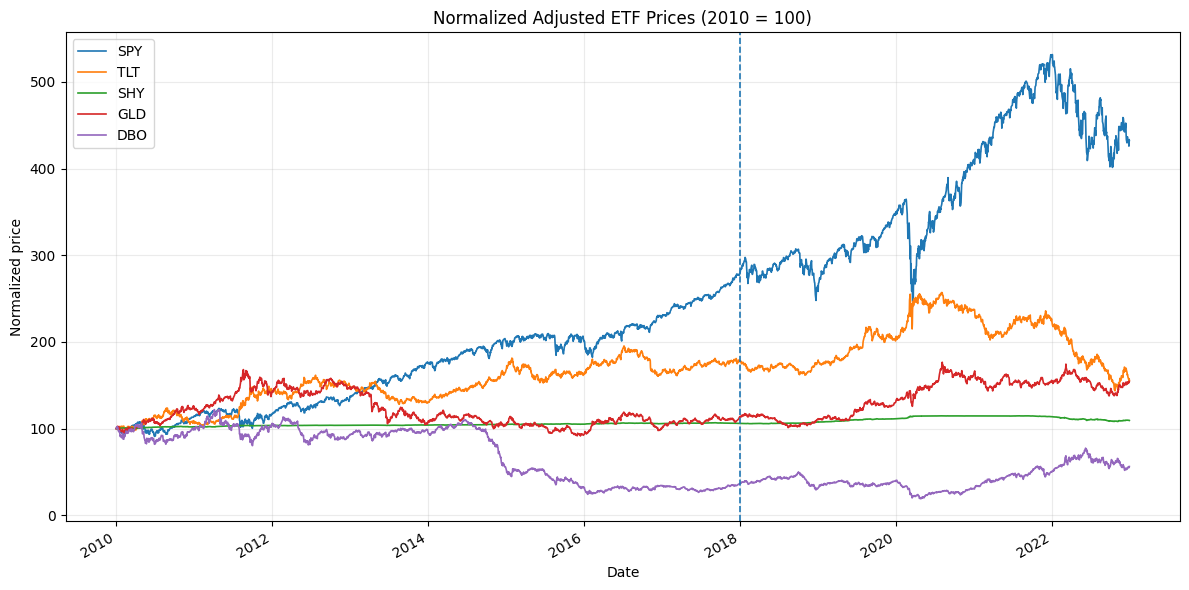

In [5]:
normalized = prices / prices.iloc[0] * 100.0

ax = normalized.plot(figsize=(12, 6), linewidth=1.2)
ax.axvline(TEST_START, linestyle="--", linewidth=1.2, label="Test period starts")
ax.set_title("Normalized Adjusted ETF Prices (2010 = 100)")
ax.set_xlabel("Date")
ax.set_ylabel("Normalized price")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig1_normalized_prices.png", dpi=160, bbox_inches="tight")
plt.show()

## 1.4 Summary statistics and individual distributions

In [6]:
summary = pd.DataFrame(index=TICKERS)
summary["Asset class"] = pd.Series(ASSET_CLASS)
summary["Mean daily log return"] = log_returns.mean()
summary["Daily volatility"] = log_returns.std()
summary["Annualized return"] = np.exp(log_returns.mean() * 252) - 1
summary["Annualized volatility"] = log_returns.std() * np.sqrt(252)
summary["Skewness"] = log_returns.skew()
summary["Excess kurtosis"] = log_returns.kurtosis()
summary["Minimum daily return"] = log_returns.min()
summary["Maximum daily return"] = log_returns.max()

print("Step 1 summary statistics")
display(summary.round(5))
summary.to_csv(OUTPUT_DIR / "step1_summary_statistics.csv")

Step 1 summary statistics


,Asset class,Mean daily log return,Daily volatility,Annualized return,Annualized volatility,Skewness,Excess kurtosis,Minimum daily return,Maximum daily return
SPY,Equity,0.00045,0.01113,0.11940,0.17666,-0.73023,11.55915,-0.11589,0.08673
TLT,Fixed Income,0.00014,0.00951,0.03479,0.15100,-0.02619,4.14400,-0.06901,0.07250
SHY,Cash-like,0.00003,0.00069,0.00701,0.01102,0.09578,8.73058,-0.00510,0.00544
GLD,Precious Metals (Gold),0.00013,0.00990,0.03408,0.15721,-0.53683,5.15728,-0.09191,0.04787
DBO,Crude Oil,-0.00018,0.01926,-0.04327,0.30579,-0.72759,5.98519,-0.18207,0.10096


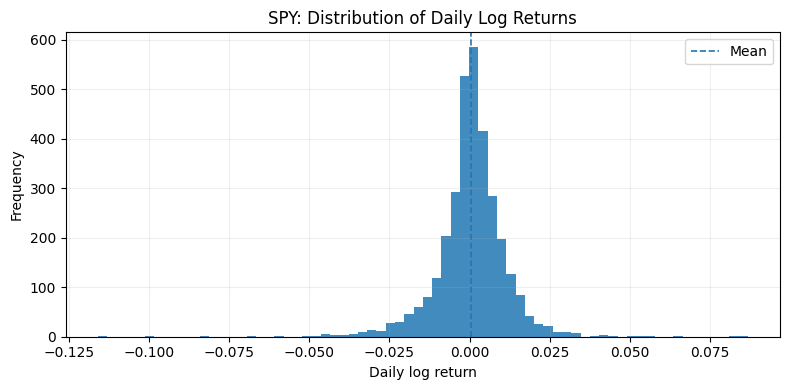

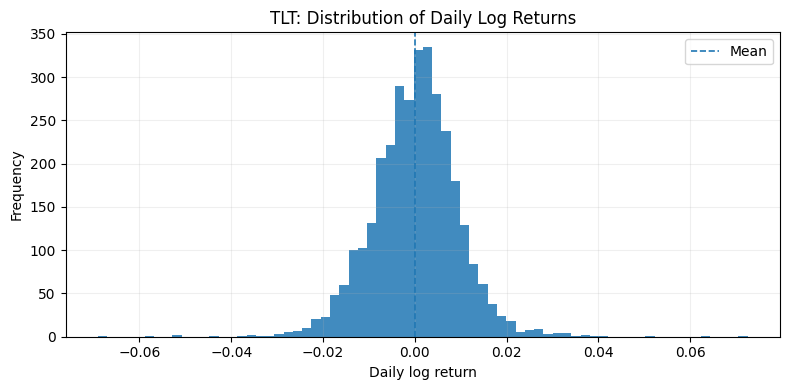

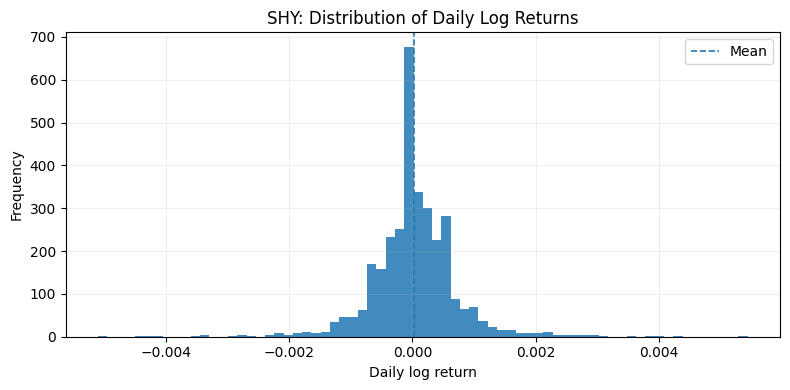

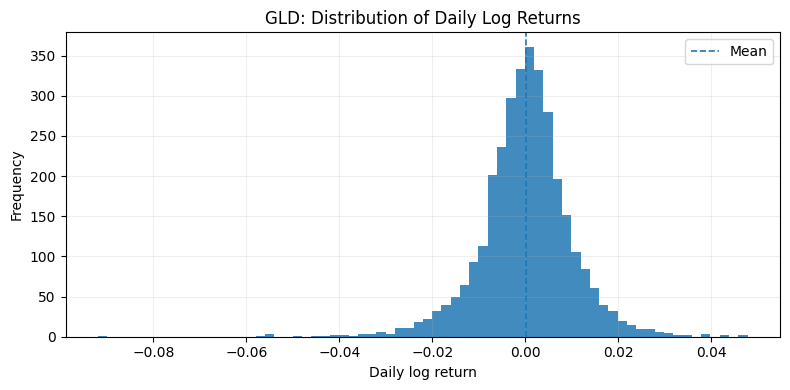

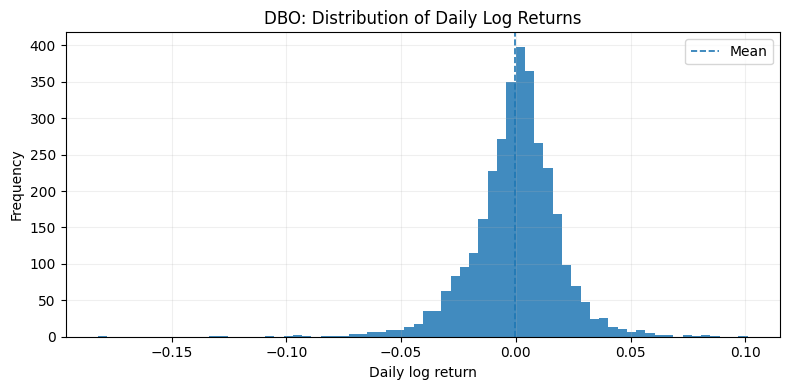

In [7]:
# One figure per ETF keeps the distributions readable.
for ticker in TICKERS:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(log_returns[ticker], bins=70, alpha=0.85)
    ax.axvline(log_returns[ticker].mean(), linestyle="--", linewidth=1.2, label="Mean")
    ax.set_title(f"{ticker}: Distribution of Daily Log Returns")
    ax.set_xlabel("Daily log return")
    ax.set_ylabel("Frequency")
    ax.legend()
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"fig_distribution_{ticker}.png", dpi=160, bbox_inches="tight")
    plt.show()

## 1.5 Joint distributions — correlation and covariance

The assignment explicitly asks that the EDA address joint distributions, including correlations/covariances.

In [8]:
correlation = log_returns.corr()
covariance = log_returns.cov()

print("Correlation matrix")
display(correlation.round(3))
print("Covariance matrix")
display(covariance.round(8))

correlation.to_csv(OUTPUT_DIR / "step1_correlation_matrix.csv")
covariance.to_csv(OUTPUT_DIR / "step1_covariance_matrix.csv")

Correlation matrix


,SPY,TLT,SHY,GLD,DBO
SPY,1.000,-0.375,-0.165,0.046,0.406
TLT,-0.375,1.000,0.572,0.219,-0.265
SHY,-0.165,0.572,1.000,0.287,-0.139
GLD,0.046,0.219,0.287,1.000,0.145
DBO,0.406,-0.265,-0.139,0.145,1.000


Covariance matrix


,SPY,TLT,SHY,GLD,DBO
SPY,0.000124,-0.000040,-1.270000e-06,0.000005,0.000087
TLT,-0.000040,0.000090,3.780000e-06,0.000021,-0.000049
SHY,-0.000001,0.000004,4.800000e-07,0.000002,-0.000002
GLD,0.000005,0.000021,1.970000e-06,0.000098,0.000028
DBO,0.000087,-0.000049,-1.860000e-06,0.000028,0.000371


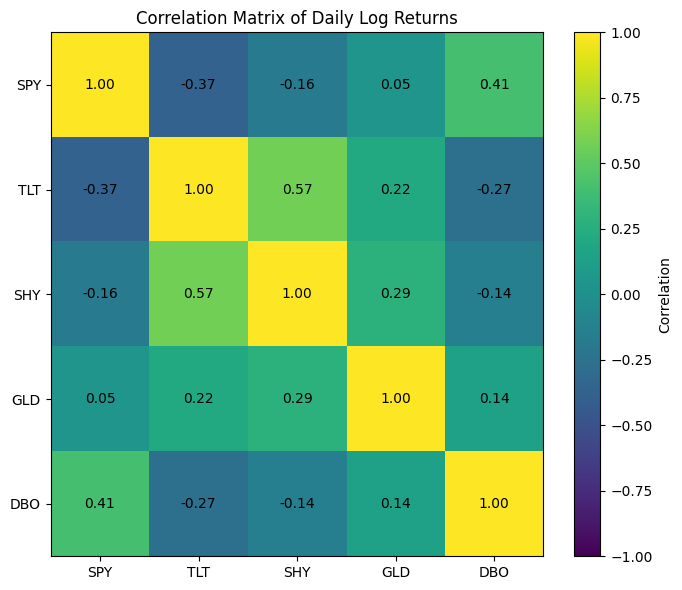

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(correlation.values, vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(TICKERS)), TICKERS)
ax.set_yticks(range(len(TICKERS)), TICKERS)
ax.set_title("Correlation Matrix of Daily Log Returns")

for i in range(len(TICKERS)):
    for j in range(len(TICKERS)):
        ax.text(j, i, f"{correlation.iloc[i, j]:.2f}", ha="center", va="center")

fig.colorbar(im, ax=ax, label="Correlation")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_correlation_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

## 1.6 Rolling volatility

A 21-trading-day window approximates one trading month and helps reveal volatility clustering and changing market regimes.

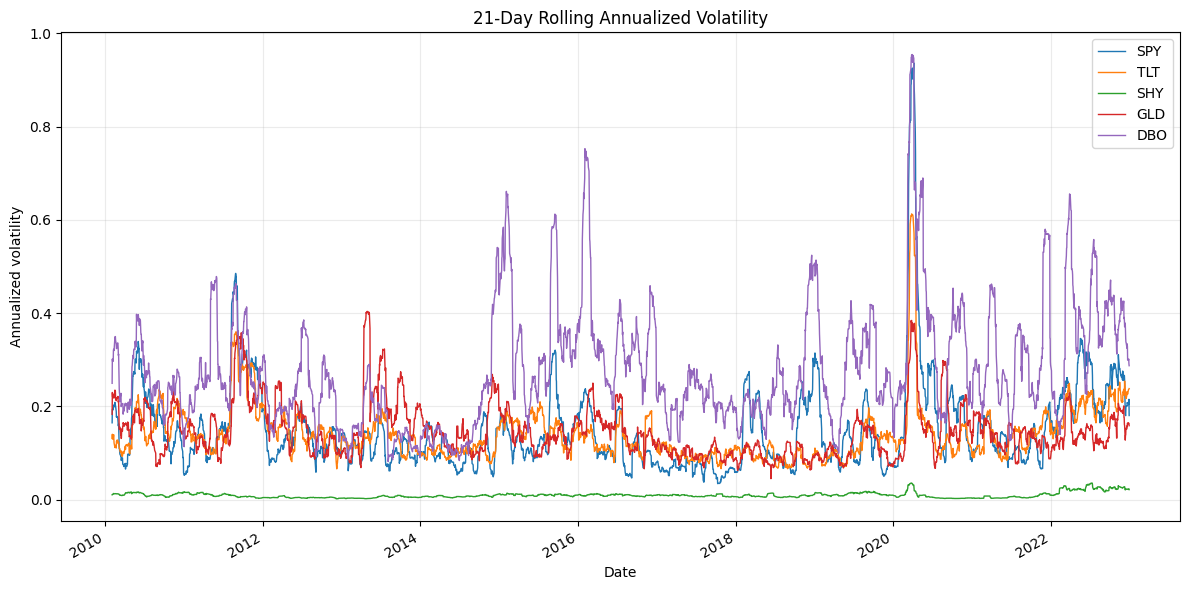

In [10]:
rolling_vol = log_returns.rolling(21).std() * np.sqrt(252)

ax = rolling_vol.plot(figsize=(12, 6), linewidth=1.0)
ax.set_title("21-Day Rolling Annualized Volatility")
ax.set_xlabel("Date")
ax.set_ylabel("Annualized volatility")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_rolling_volatility.png", dpi=160, bbox_inches="tight")
plt.show()

## 1.7 Seasonality — average monthly log return by calendar month

Daily log returns are first aggregated within each calendar month, then averaged by month-of-year. This is a brief descriptive seasonality check rather than a trading rule.

,SPY,TLT,SHY,GLD,DBO
Calendar month,,,,,
1,0.00248,0.01119,0.00180,0.02141,-0.00726
2,0.01283,-0.00532,0.00017,0.00804,0.01953
3,0.00961,-0.00177,0.00041,-0.00536,-0.00634
4,0.01625,0.00304,0.00096,0.01545,0.02642
5,-0.00405,0.01362,0.00197,-0.01044,-0.02480
6,-0.00057,0.00486,0.00035,-0.00061,0.01074
7,0.03029,0.01581,0.00116,0.00956,-0.01290
8,-0.00451,0.01728,0.00066,0.02609,-0.00834
9,-0.00826,-0.00963,-0.00089,-0.02532,-0.01264


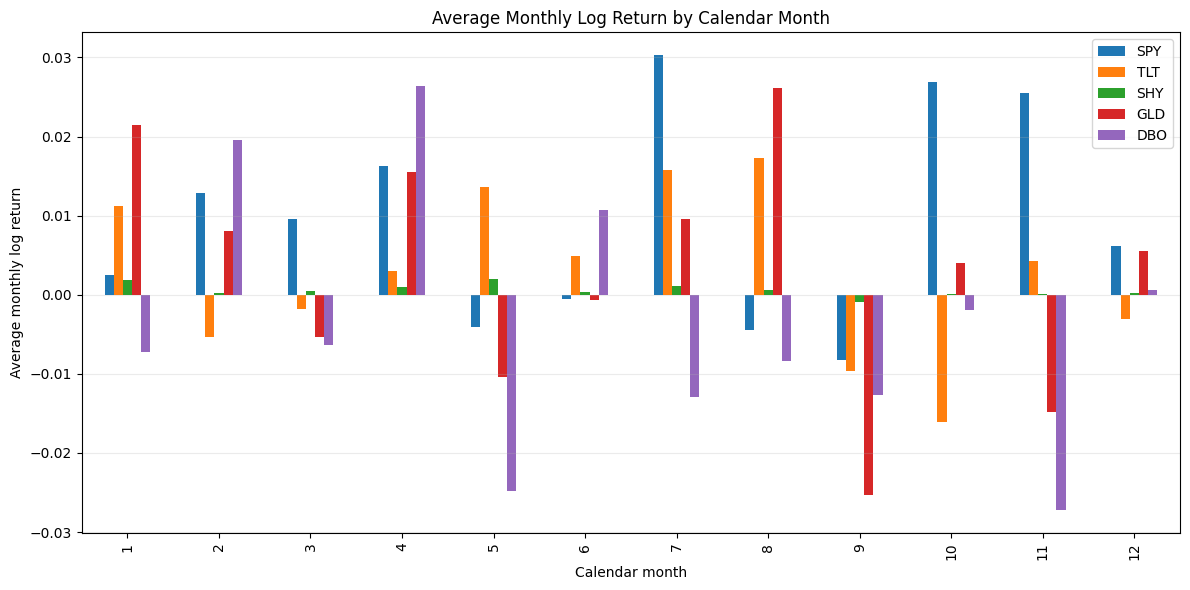

In [11]:
monthly_returns = log_returns.resample("ME").sum()
seasonality = monthly_returns.groupby(monthly_returns.index.month).mean()
seasonality.index.name = "Calendar month"

display(seasonality.round(5))
seasonality.to_csv(OUTPUT_DIR / "step1_monthly_seasonality.csv")

ax = seasonality.plot(kind="bar", figsize=(12, 6))
ax.set_title("Average Monthly Log Return by Calendar Month")
ax.set_xlabel("Calendar month")
ax.set_ylabel("Average monthly log return")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_monthly_seasonality.png", dpi=160, bbox_inches="tight")
plt.show()

## 1.8 Stationarity — Augmented Dickey-Fuller tests

The ADF null hypothesis is that the series contains a unit root. We test both log price levels and daily log returns. The model ultimately receives daily log returns, so the return-series ADF result is the direct justification required for Step 1.

In [12]:
def run_adf(df, label):
    rows = []
    for col in df.columns:
        x = df[col].dropna()
        stat, pvalue, usedlag, nobs, crit, icbest = adfuller(x, autolag="AIC")
        rows.append({
            "Series": label,
            "ETF": col,
            "ADF statistic": stat,
            "p-value": pvalue,
            "Used lags": usedlag,
            "Observations": nobs,
            "5% critical value": crit["5%"],
            "Reject unit root at 5%?": "Yes" if pvalue < 0.05 else "No",
        })
    return pd.DataFrame(rows)

adf_prices = run_adf(np.log(prices), "Log price")
adf_returns = run_adf(log_returns, "Daily log return")
adf_results = pd.concat([adf_prices, adf_returns], ignore_index=True)

display(adf_results.round(6))
adf_results.to_csv(OUTPUT_DIR / "step1_adf_results.csv", index=False)

,Series,ETF,ADF statistic,p-value,Used lags,Observations,5% critical value,Reject unit root at 5%?
0,Log price,SPY,-1.056678,0.732036,27,3244,-2.862431,No
1,Log price,TLT,-2.170391,0.217167,25,3246,-2.862431,No
2,Log price,SHY,-1.452691,0.556771,18,3253,-2.862429,No
3,Log price,GLD,-1.740824,0.410211,0,3271,-2.862424,No
4,Log price,DBO,-1.409907,0.577518,1,3270,-2.862424,No
5,Daily log return,SPY,-12.390321,0.000000,26,3244,-2.862431,Yes
6,Daily log return,TLT,-10.540261,0.000000,24,3246,-2.862431,Yes
7,Daily log return,SHY,-11.864397,0.000000,17,3253,-2.862429,Yes
8,Daily log return,GLD,-57.655431,0.000000,0,3270,-2.862424,Yes
9,Daily log return,DBO,-60.054842,0.000000,0,3270,-2.862424,Yes


# Step 2 — MLP models for 25-day-ahead returns

For each ETF, we train a separate regression MLP using **only its own past return history**, as requested.

### Common architecture used for all five assets
- Input: 60 lagged daily log returns
- Dense(64, ReLU)
- Dropout(0.20)
- Dense(32, ReLU)
- Dropout(0.10)
- Dense(1, linear output)
- Optimizer: Adam, learning rate 0.001
- Loss: mean squared error
- Batch size: 32
- Maximum epochs: 250
- Early stopping: validation loss, patience 15, restore best weights

Using the same architecture across ETFs makes the cross-asset performance comparison more interpretable.

## 2.1 Construct supervised samples without look-ahead leakage

At feature date \(t\), the model sees the previous 60 daily returns through \(t\) and predicts the cumulative log return from \(t\) to \(t+25\). Samples are assigned to training, validation, or test according to the **target date**.

In [13]:
def make_supervised(price_series, lags=LAGS, horizon=HORIZON):
    price_series = price_series.dropna().copy()
    r = np.log(price_series / price_series.shift(1))
    idx = price_series.index

    records = []
    for i in range(lags, len(price_series) - horizon):
        feature_date = idx[i]
        target_date = idx[i + horizon]
        x = r.iloc[i-lags+1:i+1].to_numpy(dtype=float)
        if np.isnan(x).any():
            continue
        y = float(np.log(price_series.iloc[i + horizon] / price_series.iloc[i]))
        records.append((feature_date, target_date, *x, y))

    cols = (
        ["feature_date", "target_date"]
        + [f"lag_{k}" for k in range(lags, 0, -1)]
        + ["target"]
    )
    df = pd.DataFrame(records, columns=cols)
    df["feature_date"] = pd.to_datetime(df["feature_date"])
    df["target_date"] = pd.to_datetime(df["target_date"])
    return df

supervised = {ticker: make_supervised(prices[ticker]) for ticker in TICKERS}

for ticker, df in supervised.items():
    print(ticker, df.shape, df["target_date"].min().date(), "to", df["target_date"].max().date())

SPY (3187, 63) 2010-05-06 to 2022-12-30
TLT (3187, 63) 2010-05-06 to 2022-12-30
SHY (3187, 63) 2010-05-06 to 2022-12-30
GLD (3187, 63) 2010-05-06 to 2022-12-30
DBO (3187, 63) 2010-05-06 to 2022-12-30


In [14]:
def split_by_target_date(df):
    train = df[df["target_date"] <= TRAIN_END].copy()
    validation = df[(df["target_date"] >= VAL_START) & (df["target_date"] <= VAL_END)].copy()
    test = df[(df["target_date"] >= TEST_START) & (df["target_date"] <= TEST_END)].copy()
    return train, validation, test

split_counts = []
for ticker, df in supervised.items():
    tr, va, te = split_by_target_date(df)
    split_counts.append({"ETF": ticker, "Train": len(tr), "Validation": len(va), "Test": len(te)})

split_counts = pd.DataFrame(split_counts).set_index("ETF")
display(split_counts)
split_counts.to_csv(OUTPUT_DIR / "step2_split_counts.csv")

,Train,Validation,Test
ETF,,,
SPY,1425,503,1259
TLT,1425,503,1259
SHY,1425,503,1259
GLD,1425,503,1259
DBO,1425,503,1259


## 2.2 Define the MLP and evaluation metrics

We report RMSE, MAE, R-squared, prediction/realization correlation, and directional accuracy. We also report a **zero-return baseline RMSE** for context. All scaling parameters are estimated from the training sample only.

In [15]:
def build_mlp(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(64, activation="relu"),
        Dropout(0.20),
        Dense(32, activation="relu"),
        Dropout(0.10),
        Dense(1),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"],
    )
    return model


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    corr = np.corrcoef(y_true, y_pred)[0, 1] if np.std(y_pred) > 0 else np.nan
    directional_accuracy = np.mean(np.sign(y_true) == np.sign(y_pred))
    baseline_rmse = np.sqrt(mean_squared_error(y_true, np.zeros_like(y_true)))

    return {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Prediction correlation": corr,
        "Directional accuracy": directional_accuracy,
        "Zero-return baseline RMSE": baseline_rmse,
        "RMSE improvement vs baseline": 1 - rmse / baseline_rmse,
    }

## 2.3 Train one MLP per ETF

In [16]:
feature_cols = [f"lag_{k}" for k in range(LAGS, 0, -1)]

models = {}
histories = {}
predictions = {}
rows = []

for ticker in TICKERS:
    print(f"\n===== {ticker} ({ASSET_CLASS[ticker]}) =====")
    train, validation, test = split_by_target_date(supervised[ticker])

    X_train = train[feature_cols].to_numpy()
    X_val = validation[feature_cols].to_numpy()
    X_test = test[feature_cols].to_numpy()

    y_train = train[["target"]].to_numpy()
    y_val = validation[["target"]].to_numpy()
    y_test = test[["target"]].to_numpy()

    # Fit scalers on training data only.
    x_scaler = StandardScaler().fit(X_train)
    y_scaler = StandardScaler().fit(y_train)

    X_train_s = x_scaler.transform(X_train)
    X_val_s = x_scaler.transform(X_val)
    X_test_s = x_scaler.transform(X_test)

    y_train_s = y_scaler.transform(y_train)
    y_val_s = y_scaler.transform(y_val)

    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    model = build_mlp(X_train_s.shape[1])

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=15,
        min_delta=1e-5,
        restore_best_weights=True,
        verbose=0,
    )

    history = model.fit(
        X_train_s,
        y_train_s,
        validation_data=(X_val_s, y_val_s),
        epochs=250,
        batch_size=32,
        shuffle=False,
        verbose=0,
        callbacks=[early_stop],
    )

    def predict_unscaled(Xs):
        scaled = model.predict(Xs, verbose=0)
        return y_scaler.inverse_transform(scaled).reshape(-1)

    pred_train = predict_unscaled(X_train_s)
    pred_val = predict_unscaled(X_val_s)
    pred_test = predict_unscaled(X_test_s)

    for split_name, y_true, y_pred in [
        ("Train", y_train.reshape(-1), pred_train),
        ("Validation", y_val.reshape(-1), pred_val),
        ("Test", y_test.reshape(-1), pred_test),
    ]:
        row = {"ETF": ticker, "Asset class": ASSET_CLASS[ticker], "Split": split_name}
        row.update(regression_metrics(y_true, y_pred))
        rows.append(row)

    models[ticker] = model
    histories[ticker] = history.history
    predictions[ticker] = pd.DataFrame({
        "Actual": y_test.reshape(-1),
        "Predicted": pred_test,
    }, index=pd.to_datetime(test["target_date"].values))
    predictions[ticker].index.name = "target_date"

results = pd.DataFrame(rows)
results.to_csv(OUTPUT_DIR / "step2_mlp_metrics_all_splits.csv", index=False)

display(results.round(5))


===== SPY (Equity) =====

===== TLT (Fixed Income) =====

===== SHY (Cash-like) =====

===== GLD (Precious Metals (Gold)) =====

===== DBO (Crude Oil) =====


,ETF,Asset class,Split,RMSE,MAE,R2,Prediction correlation,Directional accuracy,Zero-return baseline RMSE,RMSE improvement vs baseline
0,SPY,Equity,Train,0.03585,0.02656,0.20056,0.52259,0.71579,0.04172,0.14083
1,SPY,Equity,Validation,0.03122,0.02213,-0.06275,0.00095,0.76342,0.03364,0.07179
2,SPY,Equity,Test,0.06099,0.04141,0.00961,0.15625,0.66720,0.06201,0.01642
3,TLT,Fixed Income,Train,0.03527,0.02762,0.28628,0.62954,0.72140,0.04258,0.17164
4,TLT,Fixed Income,Validation,0.03464,0.02567,-0.00873,0.11198,0.59841,0.03476,0.00339
5,TLT,Fixed Income,Test,0.04805,0.03710,-0.04741,0.06314,0.52343,0.04698,-0.02277
6,SHY,Cash-like,Train,0.00174,0.00131,0.34780,0.67089,0.69123,0.00229,0.23995
7,SHY,Cash-like,Validation,0.00250,0.00194,-0.06244,0.06795,0.55467,0.00247,-0.01045
8,SHY,Cash-like,Test,0.00520,0.00347,-0.02641,0.04168,0.57824,0.00517,-0.00584
9,GLD,Precious Metals (Gold),Train,0.04267,0.03364,0.31477,0.65455,0.72982,0.05157,0.17268


## 2.4 In-sample and out-of-sample comparison

In [17]:
train_results = results[results["Split"] == "Train"].copy().set_index("ETF")
val_results = results[results["Split"] == "Validation"].copy().set_index("ETF")
test_results = results[results["Split"] == "Test"].copy().set_index("ETF")

test_comparison = test_results[[
    "Asset class", "RMSE", "MAE", "R2", "Prediction correlation",
    "Directional accuracy", "Zero-return baseline RMSE", "RMSE improvement vs baseline"
]].sort_values("RMSE")

display(test_comparison.round(5))
test_comparison.to_csv(OUTPUT_DIR / "step2_test_comparison.csv")

,Asset class,RMSE,MAE,R2,Prediction correlation,Directional accuracy,Zero-return baseline RMSE,RMSE improvement vs baseline
ETF,,,,,,,,
SHY,Cash-like,0.00520,0.00347,-0.02641,0.04168,0.57824,0.00517,-0.00584
GLD,Precious Metals (Gold),0.04245,0.03343,-0.10022,0.02282,0.49484,0.04098,-0.03601
TLT,Fixed Income,0.04805,0.03710,-0.04741,0.06314,0.52343,0.04698,-0.02277
SPY,Equity,0.06099,0.04141,0.00961,0.15625,0.66720,0.06201,0.01642
DBO,Crude Oil,0.11431,0.09090,-0.09413,0.04974,0.46863,0.10965,-0.04248


## 2.5 Training curves

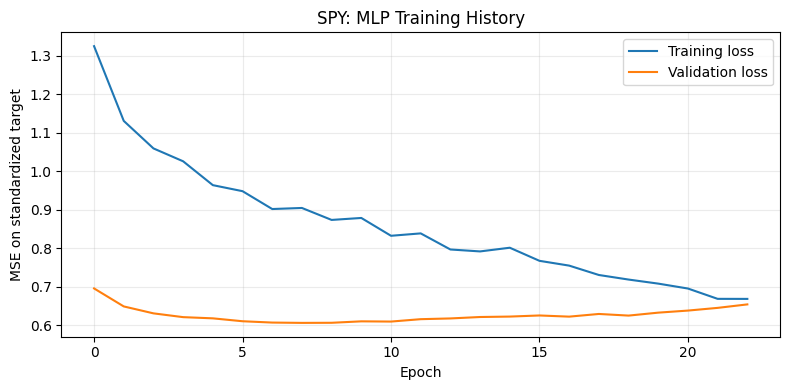

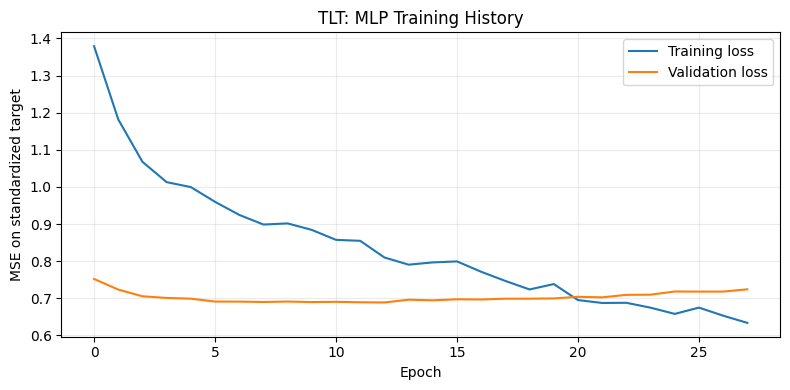

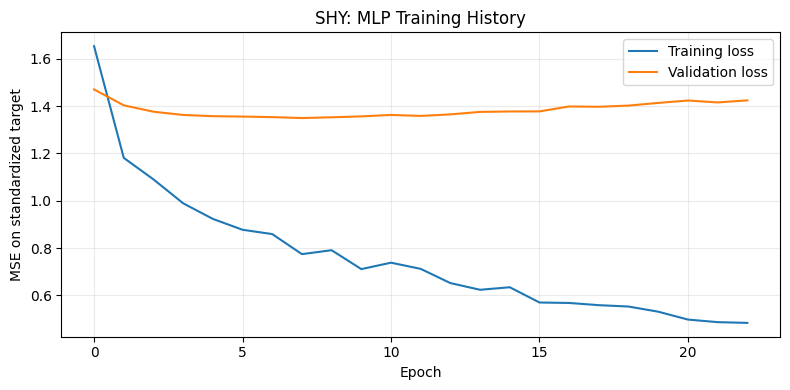

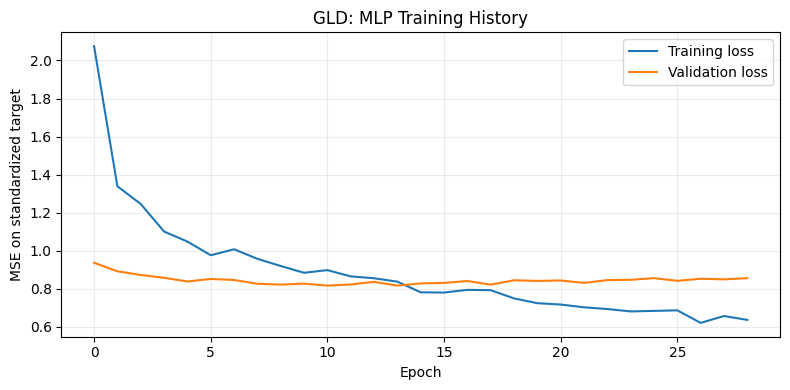

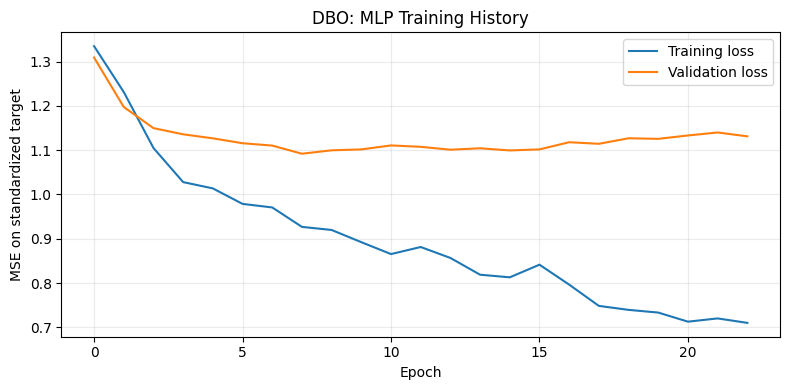

In [18]:
for ticker in TICKERS:
    h = histories[ticker]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(h["loss"], label="Training loss")
    ax.plot(h["val_loss"], label="Validation loss")
    ax.set_title(f"{ticker}: MLP Training History")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE on standardized target")
    ax.legend()
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"fig_training_history_{ticker}.png", dpi=160, bbox_inches="tight")
    plt.show()

## 2.6 Out-of-sample actual versus predicted returns

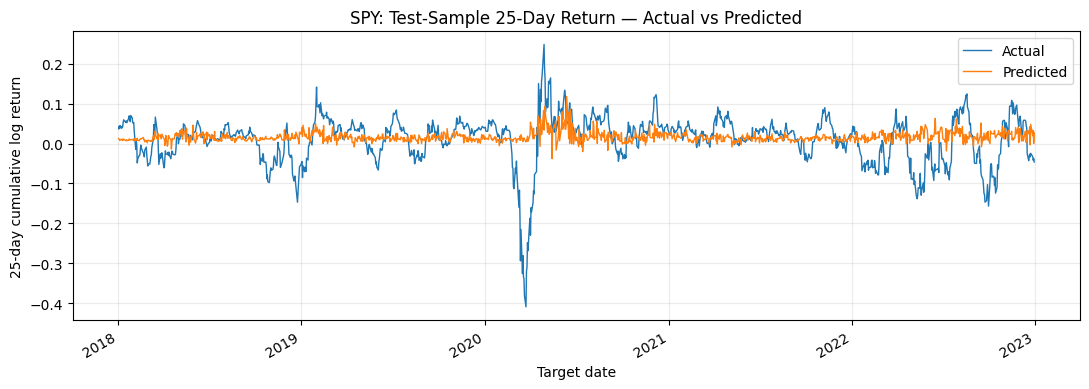

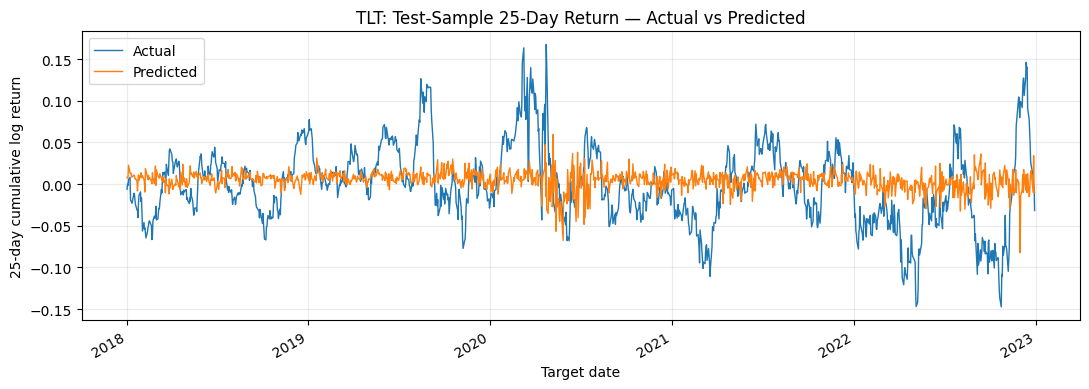

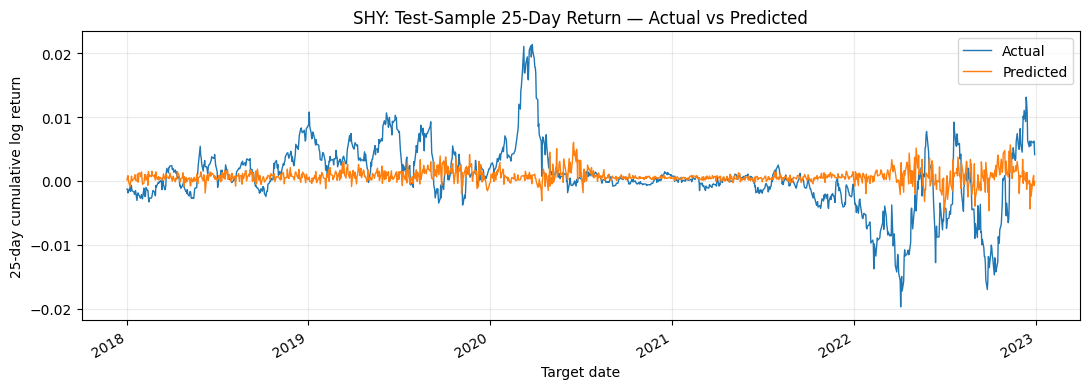

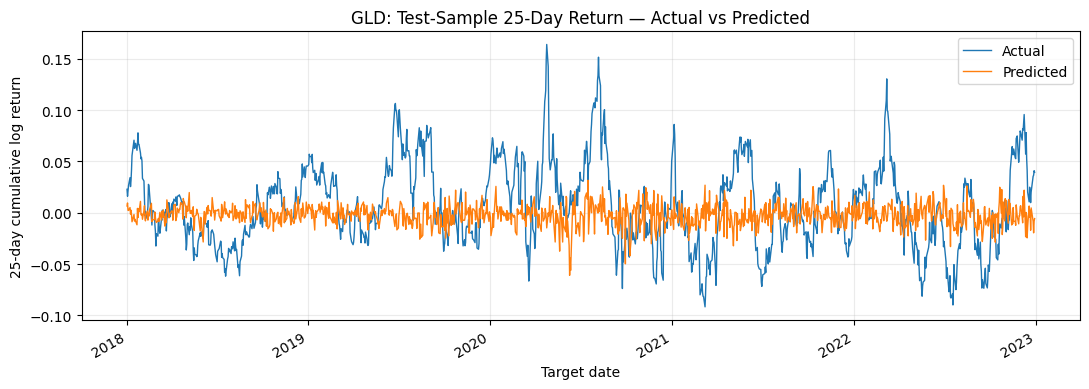

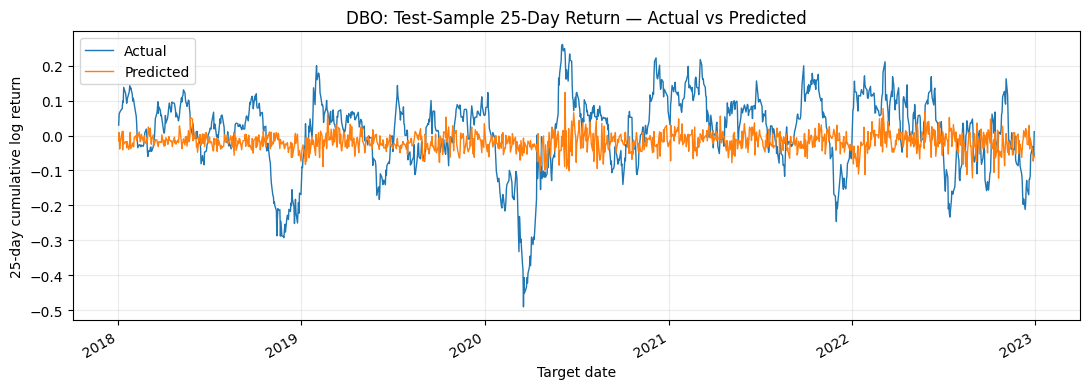

In [19]:
for ticker in TICKERS:
    p = predictions[ticker]
    ax = p.plot(figsize=(11, 4), linewidth=1.0)
    ax.set_title(f"{ticker}: Test-Sample 25-Day Return — Actual vs Predicted")
    ax.set_xlabel("Target date")
    ax.set_ylabel("25-day cumulative log return")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"fig_actual_vs_predicted_{ticker}.png", dpi=160, bbox_inches="tight")
    plt.show()
    p.to_csv(OUTPUT_DIR / f"step2_test_predictions_{ticker}.csv")

# Automatic matching report generator

The following cells build the written Step 1-2 report directly from the objects created above. This is intentional: **the numerical values in the generated report are taken from the exact same tables produced by the notebook**, so the code and report cannot silently diverge.

In [20]:
def pct(x, digits=2):
    return f"{100*x:.{digits}f}%"

def num(x, digits=4):
    return f"{x:.{digits}f}"

# ---- Step 1 facts ----
vol_rank = summary["Annualized volatility"].sort_values(ascending=False)
high_vol = vol_rank.index[0]
low_vol = vol_rank.index[-1]

# Unique off-diagonal correlation pairs
pairs = []
for i, a in enumerate(TICKERS):
    for j in range(i + 1, len(TICKERS)):
        b = TICKERS[j]
        pairs.append((a, b, correlation.loc[a, b]))
strong_pos = max(pairs, key=lambda x: x[2])
weakest = min(pairs, key=lambda x: x[2])

adf_ret = adf_returns.set_index("ETF")
stationary_all = bool((adf_ret["p-value"] < 0.05).all())

# ---- Step 2 facts ----
best_rmse = test_results["RMSE"].idxmin()
worst_rmse = test_results["RMSE"].idxmax()
best_direction = test_results["Directional accuracy"].idxmax()
best_corr = test_results["Prediction correlation"].idxmax()

# Generalization gap based on RMSE
rmse_gap = (test_results["RMSE"] / train_results["RMSE"]).sort_values(ascending=False)
max_gap_asset = rmse_gap.index[0]

positive_r2 = test_results.index[test_results["R2"] > 0].tolist()
beat_baseline = test_results.index[test_results["RMSE improvement vs baseline"] > 0].tolist()

# Text snippets conditioned on results
stationarity_sentence = (
    "All five daily log-return series reject the ADF unit-root null at the 5% level, supporting the use of daily log returns as the stationary model input."
    if stationary_all else
    "Most return series reject the ADF unit-root null at the 5% level; any exception is identified in Table 3 and should be treated cautiously in the model interpretation."
)

if positive_r2:
    r2_sentence = (
        "Positive out-of-sample R-squared was obtained for " + ", ".join(positive_r2) +
        ", while the remaining assets had non-positive R-squared values."
    )
else:
    r2_sentence = (
        "All five out-of-sample R-squared values were non-positive, indicating that the MLPs did not outperform a constant-mean benchmark in terms of variance explained."
    )

if beat_baseline:
    baseline_sentence = (
        "The MLP achieved lower RMSE than the zero-return baseline for " + ", ".join(beat_baseline) + "."
    )
else:
    baseline_sentence = (
        "None of the MLPs achieved lower RMSE than the zero-return baseline, so practical predictive value is weak under this specification."
    )

# Tables formatted for plain-text report
summary_report = summary[["Annualized return", "Annualized volatility", "Skewness", "Excess kurtosis"]].copy()
summary_report["Annualized return"] = summary_report["Annualized return"].map(lambda x: pct(x))
summary_report["Annualized volatility"] = summary_report["Annualized volatility"].map(lambda x: pct(x))
summary_report["Skewness"] = summary_report["Skewness"].map(lambda x: num(x, 3))
summary_report["Excess kurtosis"] = summary_report["Excess kurtosis"].map(lambda x: num(x, 3))

adf_report = adf_ret[["ADF statistic", "p-value", "Reject unit root at 5%?"]].copy()
adf_report["ADF statistic"] = adf_report["ADF statistic"].map(lambda x: num(x, 3))
adf_report["p-value"] = adf_report["p-value"].map(lambda x: f"{x:.6g}")

test_report = test_results[["RMSE", "MAE", "R2", "Prediction correlation", "Directional accuracy", "RMSE improvement vs baseline"]].copy()
for c in ["RMSE", "MAE", "R2", "Prediction correlation"]:
    test_report[c] = test_report[c].map(lambda x: num(x, 4))
test_report["Directional accuracy"] = test_report["Directional accuracy"].map(lambda x: pct(x))
test_report["RMSE improvement vs baseline"] = test_report["RMSE improvement vs baseline"].map(lambda x: pct(x))

In [21]:
report = f"""
MScFE 642 DEEP LEARNING FOR FINANCE
GROUP WORK PROJECT 1 — STEPS 1 AND 2
Student Group 17444

STEP 1 — DATA COLLECTION AND EXPLORATORY DATA ANALYSIS

1. Data and sample design

Daily adjusted closing prices were downloaded with the yfinance library for five exchange-traded funds representing the asset classes specified in the assignment: SPY (equity), TLT (fixed income), SHY (cash-like), GLD (gold), and DBO (crude oil). The raw sample begins on 1 January 2010. Training targets end on 31 December 2015, validation targets cover 1 January 2016 through 31 December 2017, and the out-of-sample test period is 1 January 2018 through 30 December 2022. These dates are identical to those used in the accompanying notebook.

Adjusted prices were converted to daily log returns, r_t = ln(P_t/P_(t-1)). This representation was selected because the forecasting models require a stable time-series input and because the assignment permits any justified stationary representation. Log returns are also additive across time, so the 25-day target in Step 2 equals the sum of the next 25 daily log returns.

2. Price and return characteristics

The normalized-price chart shows materially different long-run paths across the five asset classes. The descriptive statistics reinforce this heterogeneity. {high_vol} ({ASSET_CLASS[high_vol]}) had the highest annualized volatility at {pct(summary.loc[high_vol, 'Annualized volatility'])}, while {low_vol} ({ASSET_CLASS[low_vol]}) had the lowest at {pct(summary.loc[low_vol, 'Annualized volatility'])}. Return histograms and the skewness/kurtosis statistics show that the distributions are not perfectly symmetric or Gaussian; large tail observations are visible for several assets. The 21-day rolling-volatility chart also shows volatility clustering and strong changes in market conditions over time, especially around stress periods contained in the test sample.

Table 1. Selected descriptive statistics
{summary_report.to_string()}

3. Joint distribution and diversification properties

The daily-return correlation matrix shows that the five ETFs do not move together uniformly. The strongest positive pairwise correlation is {strong_pos[0]}–{strong_pos[1]} at {strong_pos[2]:.3f}. The weakest pairwise correlation is {weakest[0]}–{weakest[1]} at {weakest[2]:.3f}. This cross-asset variation is consistent with the diversification motivation of a multi-asset portfolio: the asset classes respond differently to market regimes. The covariance matrix is reported separately in the notebook output because covariance reflects both co-movement and each asset's scale of volatility.

Table 2. Daily log-return correlation matrix
{correlation.round(3).to_string()}

4. Seasonality and stationarity

Average monthly returns by calendar month were inspected as a concise seasonality diagnostic. The pattern is descriptive rather than a trading rule; month-of-year averages vary across ETFs and should not be interpreted as stable forecasting relationships without further testing.

{stationarity_sentence}

Table 3. ADF tests on the model input series
{adf_report.to_string()}

Based on the ADF evidence and the stable mean-reverting appearance of the daily-return plots relative to price levels, daily log returns are used as the input representation for Step 2.

STEP 2 — MULTI-LAYER PERCEPTRON MODELS

1. Forecasting problem and model design

A separate Multi-Layer Perceptron (MLP) was estimated for each ETF. Each model uses only past information from its own ETF, as required by the assignment. The input vector contains the previous 60 daily log returns. The target is the cumulative log return over the next 25 trading days, y_t = ln(P_(t+25)/P_t).

The common network architecture is 60 inputs, a 64-unit ReLU dense layer, 20% dropout, a 32-unit ReLU dense layer, 10% dropout, and one linear output. All five models use Adam with a learning rate of 0.001 and mean squared error loss. The maximum number of epochs is 250 with batch size 32. Early stopping monitors validation loss with patience of 15 epochs and restores the best weights. Training observations are not shuffled because the observations are time ordered.

Both input and target standardization are fitted only on the training sample and then applied to validation and test observations. Samples are assigned to train, validation, and test sets according to the target date, not merely the feature date. This prevents a target that extends into the future test period from being treated as a training observation.

2. In-sample predictive performance

The training and validation results should be interpreted together rather than using training loss alone. A model with very low training error but much higher validation error is evidence of limited generalization. Across the five assets, the largest test-to-training RMSE ratio occurs for {max_gap_asset}, indicating the largest deterioration from fit to out-of-sample forecasting among the five models. The training-history figures in the notebook show how early stopping limits continued fitting once validation loss stops improving.

3. Out-of-sample predictive performance

Out-of-sample performance is the main basis for comparing the asset classes. {best_rmse} has the lowest test RMSE ({test_results.loc[best_rmse, 'RMSE']:.4f}), whereas {worst_rmse} has the highest ({test_results.loc[worst_rmse, 'RMSE']:.4f}). The highest directional accuracy is achieved by {best_direction} at {pct(test_results.loc[best_direction, 'Directional accuracy'])}. The highest prediction/realization correlation is obtained for {best_corr} at {test_results.loc[best_corr, 'Prediction correlation']:.3f}.

{r2_sentence} {baseline_sentence}

Table 4. Out-of-sample MLP comparison
{test_report.to_string()}

4. Comparative interpretation across asset classes

The results show that predictability is heterogeneous across asset classes. The model with the lowest training loss is not automatically the model with the strongest test performance, so model selection should emphasize out-of-sample RMSE, prediction correlation, directional accuracy, and performance relative to the simple zero-return baseline. Differences across SPY, TLT, SHY, GLD, and DBO are economically plausible because these instruments have different volatility levels, tail behavior, autocorrelation structure, and sensitivity to market regimes. However, the present exercise uses only each asset's own lagged returns, so it cannot exploit cross-asset information.

The test-period actual-versus-predicted charts also show whether the models capture broad direction while missing return magnitude, or whether predictions remain close to a constant level. Where R-squared is negative or directional accuracy is near 50%, predictive evidence should be described as weak rather than overstated.

5. Practical takeaway

For an investment decision, the Step 2 models should be treated as baseline nonlinear forecasting models rather than as standalone trading systems. A useful model would need to show persistent out-of-sample improvement over a simple benchmark and stable directional performance. Assets that combine low test error, positive prediction correlation, and directional accuracy above 50% provide the strongest candidates for further modeling in the later CNN and recurrent-network steps of the assignment.

REFERENCES — MLA STYLE

Dickey, David A., and Wayne A. Fuller. “Distribution of the Estimators for Autoregressive Time Series with a Unit Root.” Journal of the American Statistical Association, vol. 74, no. 366a, 1979, pp. 427–431.

Goodfellow, Ian, Yoshua Bengio, and Aaron Courville. Deep Learning. MIT Press, 2016.

WorldQuant University. MScFE 642 Deep Learning for Finance: Group Work Project 1. Revised 15 May 2026.

Yahoo Finance. Historical Market Data for SPY, TLT, SHY, GLD, and DBO. Accessed through the yfinance Python library.
""".strip()

print(report)

report_path = OUTPUT_DIR / "MScFE642_GWP1_Steps1_2_Report_FINAL.txt"
report_path.write_text(report, encoding="utf-8")
print("\nSaved matching report to:", report_path.resolve())

MScFE 642 DEEP LEARNING FOR FINANCE
GROUP WORK PROJECT 1 — STEPS 1 AND 2
Student Group 17444

STEP 1 — DATA COLLECTION AND EXPLORATORY DATA ANALYSIS

1. Data and sample design

Daily adjusted closing prices were downloaded with the yfinance library for five exchange-traded funds representing the asset classes specified in the assignment: SPY (equity), TLT (fixed income), SHY (cash-like), GLD (gold), and DBO (crude oil). The raw sample begins on 1 January 2010. Training targets end on 31 December 2015, validation targets cover 1 January 2016 through 31 December 2017, and the out-of-sample test period is 1 January 2018 through 30 December 2022. These dates are identical to those used in the accompanying notebook.

Adjusted prices were converted to daily log returns, r_t = ln(P_t/P_(t-1)). This representation was selected because the forecasting models require a stable time-series input and because the assignment permits any justified stationary representation. Log returns are also additi

## Files produced by this notebook

After **Run All**, the `gwp1_steps1_2_outputs` folder contains:

- adjusted prices and daily log returns;
- Step 1 summary, correlation, covariance, seasonality, and ADF CSV files;
- Step 1 figures;
- train/validation/test counts;
- all MLP metrics and the out-of-sample comparison table;
- actual-versus-predicted CSVs and figures for each ETF;
- **`MScFE642_GWP1_Steps1_2_Report_FINAL.txt`**, whose values come directly from the notebook's computed results.

This last file is the report to transfer into the group's WQU report template.

# Step 3 — CNN + GAF

### 3.1 Imports

In [22]:
!pip install pyts

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from pyts.image import GramianAngularField

### 3.2 Define the ETFs and modelling parameters

In [24]:
ETFS = ["SPY", "TLT", "SHY", "GLD", "DBO"]

LOOKBACK = 60
HORIZON = 25

### 3.3 Create the supervised samples

In [25]:
def create_supervised_data(returns, lookback=60, horizon=25):
    X = []
    y = []
    target_dates = []

    for i in range(lookback, len(returns) - horizon + 1):

        window = returns.iloc[i-lookback:i].values

        target = returns.iloc[i:i+horizon].sum()

        X.append(window)
        y.append(target)
        target_dates.append(returns.index[i+horizon-1])

    return (
        np.array(X),
        np.array(y),
        pd.DatetimeIndex(target_dates)
    )

In [26]:
supervised = {}

for etf in ETFS:
    X, y, dates = create_supervised_data(
        log_returns[etf],
        lookback=LOOKBACK,
        horizon=HORIZON
    )

    supervised[etf] = {
        "X": X,
        "y": y,
        "dates": dates
    }

    print(
        etf,
        "X:", X.shape,
        "y:", y.shape
    )

SPY X: (3187, 60) y: (3187,)
TLT X: (3187, 60) y: (3187,)
SHY X: (3187, 60) y: (3187,)
GLD X: (3187, 60) y: (3187,)
DBO X: (3187, 60) y: (3187,)


### 3.4 Split the observations

In [27]:
TRAIN_N = 1425
VAL_N = 503
TEST_N = 1259

In [28]:
splits = {}

for etf in ETFS:

    X = supervised[etf]["X"]
    y = supervised[etf]["y"]
    dates = supervised[etf]["dates"]

    train_end = TRAIN_N
    val_end = TRAIN_N + VAL_N

    X_train = X[:train_end]
    y_train = y[:train_end]

    X_val = X[train_end:val_end]
    y_val = y[train_end:val_end]

    X_test = X[val_end:]
    y_test = y[val_end:]

    dates_train = dates[:train_end]
    dates_val = dates[train_end:val_end]
    dates_test = dates[val_end:]

    splits[etf] = {
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
        "X_test": X_test,
        "y_test": y_test,
        "dates_train": dates_train,
        "dates_val": dates_val,
        "dates_test": dates_test
    }

    print(
        etf,
        len(X_train),
        len(X_val),
        len(X_test),
        dates_test[0],
        dates_test[-1]
    )

SPY 1425 503 1259 2018-01-02 00:00:00 2022-12-30 00:00:00
TLT 1425 503 1259 2018-01-02 00:00:00 2022-12-30 00:00:00
SHY 1425 503 1259 2018-01-02 00:00:00 2022-12-30 00:00:00
GLD 1425 503 1259 2018-01-02 00:00:00 2022-12-30 00:00:00
DBO 1425 503 1259 2018-01-02 00:00:00 2022-12-30 00:00:00


### 3.5 Scale the returns

In [29]:
def scale_windows(X_train, X_val, X_test):

    scaler = MinMaxScaler(feature_range=(-1, 1))

    scaler.fit(X_train.reshape(-1, 1))

    def transform(X):
        return scaler.transform(
            X.reshape(-1, 1)
        ).reshape(X.shape)

    return (
        transform(X_train),
        transform(X_val),
        transform(X_test),
        scaler
    )

In [30]:
for etf in ETFS:

    X_train = splits[etf]["X_train"]
    X_val = splits[etf]["X_val"]
    X_test = splits[etf]["X_test"]

    (
        X_train_scaled,
        X_val_scaled,
        X_test_scaled,
        scaler
    ) = scale_windows(
        X_train,
        X_val,
        X_test
    )

    splits[etf]["X_train_scaled"] = X_train_scaled
    splits[etf]["X_val_scaled"] = X_val_scaled
    splits[etf]["X_test_scaled"] = X_test_scaled
    splits[etf]["x_scaler"] = scaler

### 3.6 Convert the 60-day windows to GAF images

In [31]:
gaf = GramianAngularField(
    method="summation",
    sample_range=(-1, 1)
)

In [32]:
for etf in ETFS:

    X_train_scaled = splits[etf]["X_train_scaled"]
    X_val_scaled = splits[etf]["X_val_scaled"]
    X_test_scaled = splits[etf]["X_test_scaled"]

    X_train_gaf = gaf.fit_transform(X_train_scaled)
    X_val_gaf = gaf.transform(X_val_scaled)
    X_test_gaf = gaf.transform(X_test_scaled)

    splits[etf]["X_train_gaf"] = X_train_gaf
    splits[etf]["X_val_gaf"] = X_val_gaf
    splits[etf]["X_test_gaf"] = X_test_gaf

    print(
        etf,
        X_train_gaf.shape,
        X_val_gaf.shape,
        X_test_gaf.shape
    )

SPY (1425, 60, 60) (503, 60, 60) (1259, 60, 60)
TLT (1425, 60, 60) (503, 60, 60) (1259, 60, 60)
SHY (1425, 60, 60) (503, 60, 60) (1259, 60, 60)
GLD (1425, 60, 60) (503, 60, 60) (1259, 60, 60)
DBO (1425, 60, 60) (503, 60, 60) (1259, 60, 60)


In [33]:
# Add the CNN channel dimension:

for etf in ETFS:

    splits[etf]["X_train_gaf"] = (
        splits[etf]["X_train_gaf"][..., np.newaxis]
    )

    splits[etf]["X_val_gaf"] = (
        splits[etf]["X_val_gaf"][..., np.newaxis]
    )

    splits[etf]["X_test_gaf"] = (
        splits[etf]["X_test_gaf"][..., np.newaxis]
    )

### 3.7 Look at one GAF image

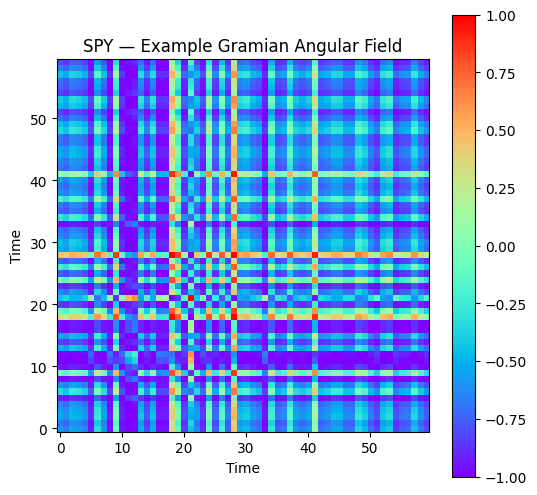

In [34]:
plt.figure(figsize=(6, 6))

plt.imshow(
    splits["SPY"]["X_train_gaf"][0, :, :, 0],
    cmap="rainbow",
    origin="lower"
)

plt.title("SPY — Example Gramian Angular Field")
plt.xlabel("Time")
plt.ylabel("Time")
plt.colorbar()

plt.show()

### 3.8 Build the CNN

In [35]:
def build_cnn(input_shape):

    model = Sequential([

        Conv2D(
            32,
            kernel_size=(3, 3),
            activation="relu",
            padding="same",
            input_shape=input_shape
        ),

        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(
            64,
            kernel_size=(3, 3),
            activation="relu",
            padding="same"
        ),

        MaxPooling2D(pool_size=(2, 2)),

        Flatten(),

        Dense(64, activation="relu"),

        Dropout(0.20),

        Dense(32, activation="relu"),

        Dropout(0.10),

        Dense(1, activation="linear")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="mse"
    )

    return model

### 3.9 Train one CNN for each ETF

In [36]:
cnn_models = {}
cnn_histories = {}

for etf in ETFS:

    print(f"\nTraining CNN for {etf}")

    X_train = splits[etf]["X_train_gaf"]
    X_val = splits[etf]["X_val_gaf"]

    y_train = splits[etf]["y_train"]
    y_val = splits[etf]["y_val"]

    model = build_cnn(X_train.shape[1:])

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=250,
        batch_size=32,
        shuffle=False,
        callbacks=[early_stop],
        verbose=1
    )

    cnn_models[etf] = model
    cnn_histories[etf] = history


Training CNN for SPY
Epoch 1/250
45/45 ━━━━━━━━━━━━━━━━━━━━ 23s 377ms/step - loss: 0.0156 - val_loss: 0.0013
Epoch 2/250
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 232ms/step - loss: 0.0017 - val_loss: 9.2061e-04
Epoch 3/250
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 198ms/step - loss: 0.0017 - val_loss: 9.2465e-04
Epoch 4/250
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 174ms/step - loss: 0.0016 - val_loss: 9.3032e-04
Epoch 5/250
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 196ms/step - loss: 0.0016 - val_loss: 9.3201e-04
Epoch 6/250
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 168ms/step - loss: 0.0016 - val_loss: 9.3009e-04
Epoch 7/250
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step - loss: 0.0016 - val_loss: 9.2786e-04
Epoch 8/250
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 196ms/step - loss: 0.0016 - val_loss: 9.2878e-04
Epoch 9/250
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 197ms/step - loss: 0.0016 - val_loss: 9.2794e-04
Epoch 10/250
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 163ms/step - loss: 0.0016 - val_loss: 9.3066e-04
Epoch 11/250
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 195ms/step - loss: 0.001

### 3.10 Evaluation function

In [37]:
def evaluate_model(model, X, y):

    predictions = model.predict(X, verbose=0).flatten()

    rmse = np.sqrt(
        mean_squared_error(y, predictions)
    )

    mae = mean_absolute_error(
        y,
        predictions
    )

    r2 = r2_score(
        y,
        predictions
    )

    correlation = np.corrcoef(
        y,
        predictions
    )[0, 1]

    directional_accuracy = (
        np.mean(
            np.sign(y) == np.sign(predictions)
        ) * 100
    )

    baseline_rmse = np.sqrt(
        np.mean(y ** 2)
    )

    improvement = (
        (baseline_rmse - rmse)
        / baseline_rmse
    ) * 100

    return {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Pred_Corr": correlation,
        "Dir_Acc": directional_accuracy,
        "Baseline_RMSE": baseline_rmse,
        "Delta_vs_Baseline_%": improvement
    }

In [38]:
cnn_results = []

for etf in ETFS:

    model = cnn_models[etf]

    for split_name in ["train", "val", "test"]:

        X = splits[etf][f"X_{split_name}_gaf"]
        y = splits[etf][f"y_{split_name}"]

        metrics = evaluate_model(
            model,
            X,
            y
        )

        metrics["ETF"] = etf
        metrics["Split"] = split_name

        cnn_results.append(metrics)

cnn_results_df = pd.DataFrame(cnn_results)

cnn_results_df = cnn_results_df[
    [
        "ETF",
        "Split",
        "RMSE",
        "MAE",
        "R2",
        "Pred_Corr",
        "Dir_Acc",
        "Baseline_RMSE",
        "Delta_vs_Baseline_%"
    ]
]

cnn_results_df

,ETF,Split,RMSE,MAE,R2,Pred_Corr,Dir_Acc,Baseline_RMSE,Delta_vs_Baseline_%
0,SPY,train,0.039867,0.029684,0.011117,0.213682,68.280702,0.041721,4.443658
1,SPY,val,0.030341,0.021307,-0.003478,0.005481,76.938370,0.033640,9.804689
2,SPY,test,0.061398,0.042241,-0.003692,0.012398,67.513900,0.062008,0.983712
3,TLT,train,0.041798,0.033057,-0.002445,NaN,57.192982,0.042576,1.828645
4,TLT,val,0.034552,0.024961,-0.003334,NaN,59.443340,0.034762,0.605485
5,TLT,test,0.047628,0.036658,-0.028969,0.010157,47.100874,0.046983,-1.372299
6,SHY,train,0.001949,0.001470,0.179987,0.529291,68.982456,0.002287,14.775891
7,SHY,val,0.002393,0.001844,0.026594,0.168814,56.262425,0.002475,3.281544
8,SHY,test,0.005122,0.003433,0.002583,0.070551,58.538523,0.005166,0.846620
9,GLD,train,0.051079,0.040744,0.018020,0.182457,54.315789,0.051574,0.960931


### 3.11 CNN vs MLP comparison

In [39]:
mlp_test_results = pd.DataFrame({
    "ETF": ["SPY", "TLT", "SHY", "GLD", "DBO"],
    "MLP_RMSE": [0.06101, 0.04803, 0.00519, 0.04245, 0.11427],
    "MLP_R2": [0.00895, -0.04653, -0.02582, -0.10022, -0.09345],
    "MLP_Corr": [0.15574, 0.06523, 0.04275, 0.02282, 0.05015],
    "MLP_Dir_Acc": [66.64, 52.11, 57.58, 49.48, 46.78]
})

cnn_test = cnn_results_df[
    cnn_results_df["Split"] == "test"
].copy()

comparison = mlp_test_results.merge(
    cnn_test,
    on="ETF"
)

comparison

,ETF,MLP_RMSE,MLP_R2,MLP_Corr,MLP_Dir_Acc,Split,RMSE,MAE,R2,Pred_Corr,Dir_Acc,Baseline_RMSE,Delta_vs_Baseline_%
0,SPY,0.06101,0.00895,0.15574,66.64,test,0.061398,0.042241,-0.003692,0.012398,67.513900,0.062008,0.983712
1,TLT,0.04803,-0.04653,0.06523,52.11,test,0.047628,0.036658,-0.028969,0.010157,47.100874,0.046983,-1.372299
2,SHY,0.00519,-0.02582,0.04275,57.58,test,0.005122,0.003433,0.002583,0.070551,58.538523,0.005166,0.846620
3,GLD,0.04245,-0.10022,0.02282,49.48,test,0.041624,0.032441,-0.057698,-0.001869,47.180302,0.040977,-1.579419
4,DBO,0.11427,-0.09345,0.05015,46.78,test,0.111554,0.088351,-0.042014,0.060251,39.555203,0.109652,-1.735147


# Step 4


===== SPY (Equity) — LSTM ====

===== TLT (Fixed Income) — LSTM ====

===== SHY (Cash-like) — LSTM ====

===== GLD (Precious Metals (Gold)) — LSTM ====

===== DBO (Crude Oil) — LSTM ====


,ETF,Asset class,Split,RMSE,MAE,R2,Prediction correlation,Directional accuracy,Zero-return baseline RMSE,RMSE improvement vs baseline
0,SPY,Equity,Train,0.03923,0.02947,0.04250,0.22097,0.68351,0.04172,0.05972
1,SPY,Equity,Validation,0.03052,0.02160,-0.01503,0.03890,0.76938,0.03364,0.09287
2,SPY,Equity,Test,0.06084,0.04222,0.01452,0.13642,0.67355,0.06201,0.01886
3,TLT,Fixed Income,Train,0.04086,0.03222,0.04196,0.24400,0.59509,0.04258,0.04027
4,TLT,Fixed Income,Validation,0.03399,0.02459,0.02926,0.22438,0.58052,0.03476,0.02233
5,TLT,Fixed Income,Test,0.04695,0.03649,0.00025,0.18132,0.49960,0.04698,0.00077
6,SHY,Cash-like,Train,0.00199,0.00147,0.14561,0.41032,0.66877,0.00229,0.13008
7,SHY,Cash-like,Validation,0.00240,0.00189,0.02447,0.22129,0.56461,0.00247,0.03176
8,SHY,Cash-like,Test,0.00567,0.00366,-0.22228,-0.38796,0.52423,0.00517,-0.09763
9,GLD,Precious Metals (Gold),Train,0.05128,0.04092,0.01040,0.13857,0.55719,0.05157,0.00577


,ETF,MLP_RMSE,MLP_R2,MLP_Dir_Acc,CNN_RMSE,CNN_R2,CNN_Dir_Acc,LSTM_RMSE,LSTM_MAE,LSTM_R2,LSTM_Corr,LSTM_Dir_Acc,Baseline_RMSE,LSTM_Delta_vs_Base
0,SPY,0.06099,0.00961,0.66720,0.06140,-0.00369,67.51390,0.06084,0.04222,0.01452,0.13642,0.67355,0.06201,0.01886
1,TLT,0.04805,-0.04741,0.52343,0.04763,-0.02897,47.10087,0.04695,0.03649,0.00025,0.18132,0.49960,0.04698,0.00077
2,SHY,0.00520,-0.02641,0.57824,0.00512,0.00258,58.53852,0.00567,0.00366,-0.22228,-0.38796,0.52423,0.00517,-0.09763
3,GLD,0.04245,-0.10022,0.49484,0.04162,-0.05770,47.18030,0.04094,0.03203,-0.02341,0.12674,0.51390,0.04098,0.00081
4,DBO,0.11431,-0.09413,0.46863,0.11155,-0.04201,39.55520,0.11128,0.08803,-0.03689,0.02850,0.39793,0.10965,-0.01485


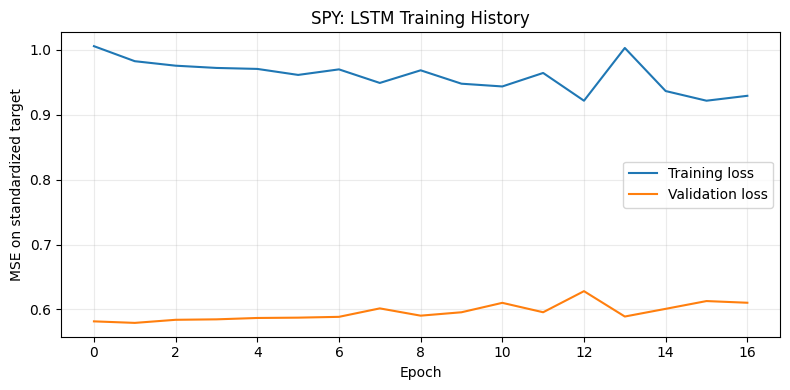

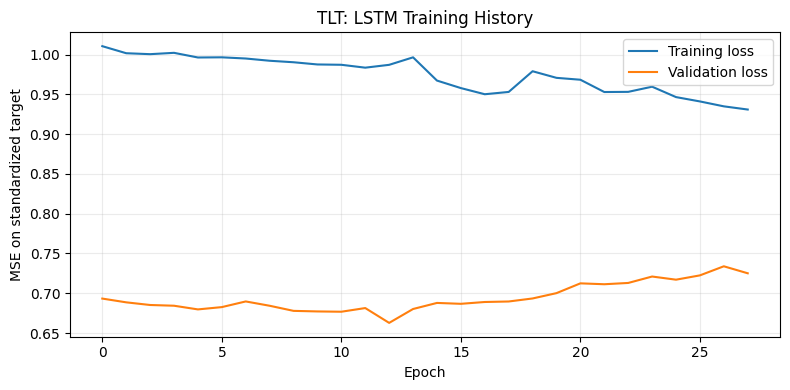

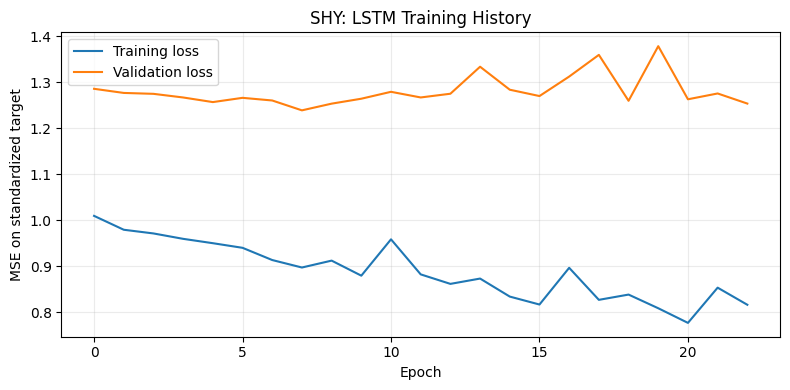

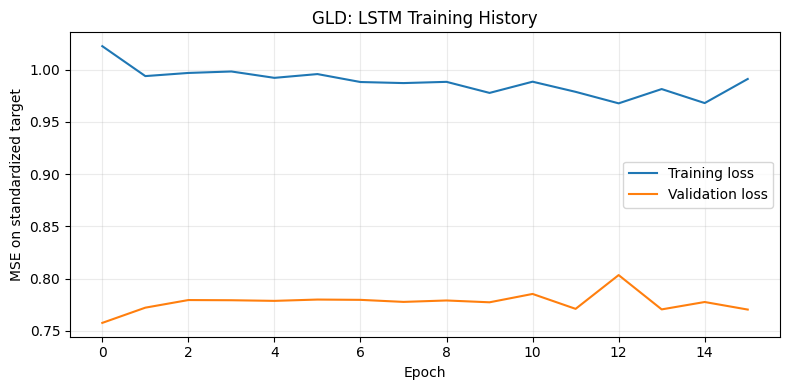

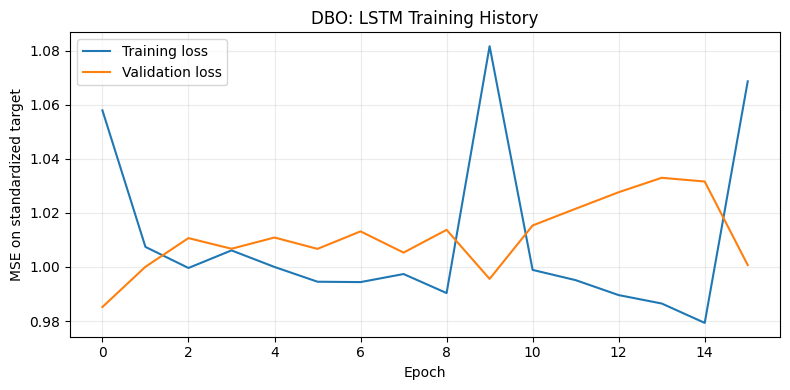

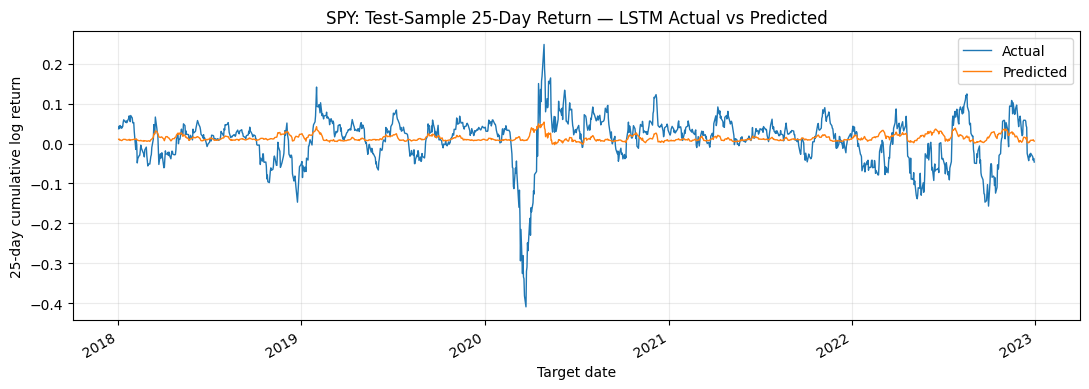

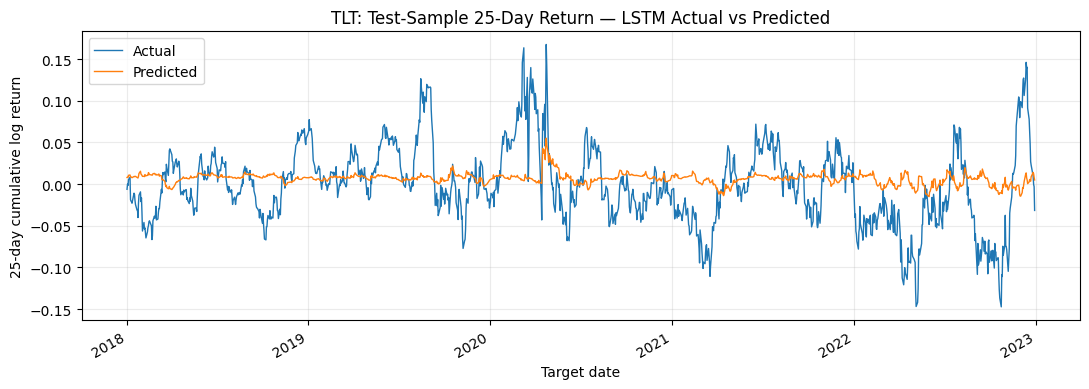

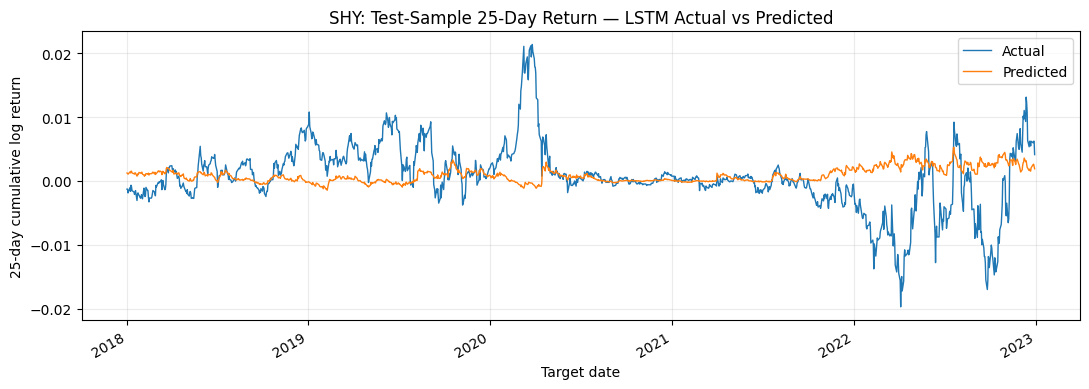

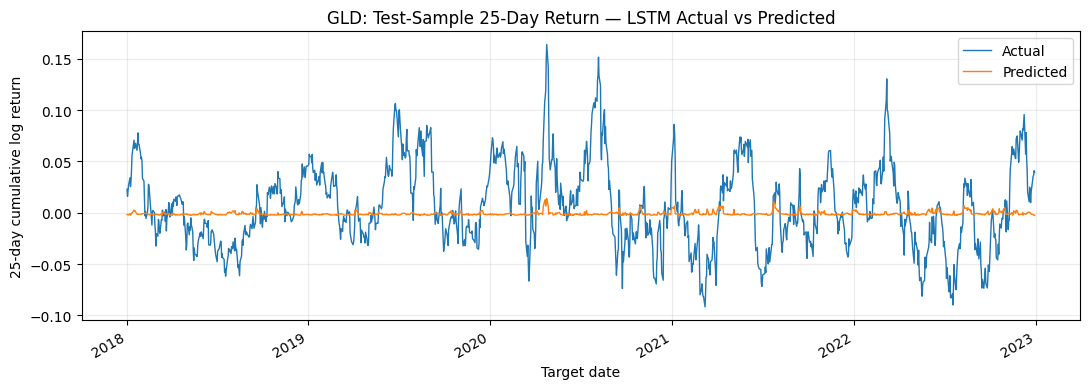

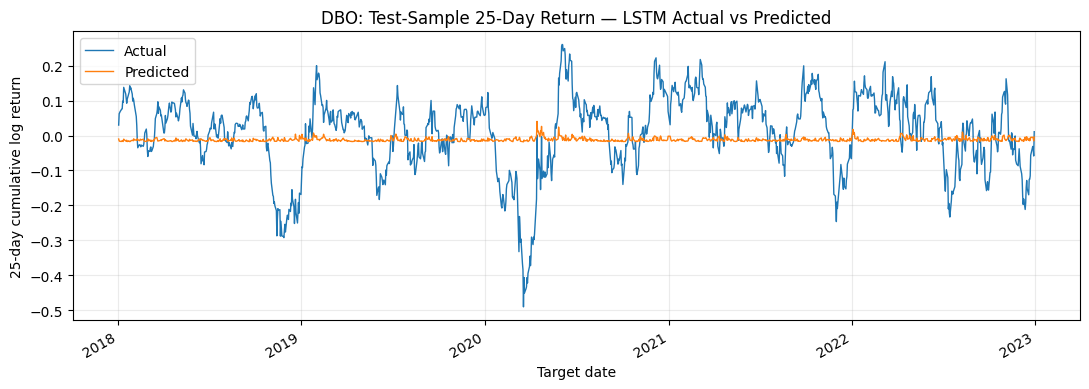

In [40]:
# Step 4: RNN (LSTM) for 25-Day-Ahead Returns
#   prices, log_returns, supervised, split_by_target_date,
#   regression_metrics, TICKERS, ASSET_CLASS, SEED, LAGS, HORIZON

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# 4.1 Build the LSTM: 60 time steps x 1 feature
# ------------------------------------------------------------
def build_lstm(time_steps, features=1):
    model = Sequential([
        Input(shape=(time_steps, features)),
        LSTM(64, activation="tanh"),
        Dropout(0.20),
        Dense(32, activation="relu"),
        Dropout(0.10),
        Dense(1),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"],
    )
    return model

# ------------------------------------------------------------
# 4.2 Train one LSTM per ETF (identical protocol to Step 2 MLP)
# ------------------------------------------------------------
feature_cols = [f"lag_{k}" for k in range(LAGS, 0, -1)]
lstm_models, lstm_histories, lstm_predictions = {}, {}, {}
rows = []

for ticker in TICKERS:
    print(f"\n===== {ticker} ({ASSET_CLASS[ticker]}) — LSTM ====")

    # Reconstruct the DataFrame expected by split_by_target_date
    current_supervised_data = supervised[ticker]
    df_for_split = pd.DataFrame(current_supervised_data["X"], columns=feature_cols)
    df_for_split["target"] = current_supervised_data["y"]
    df_for_split["target_date"] = current_supervised_data["dates"]

    train, validation, test = split_by_target_date(df_for_split)

    X_train = train[feature_cols].to_numpy()
    X_val   = validation[feature_cols].to_numpy()
    X_test  = test[feature_cols].to_numpy()
    y_train = train[["target"]].to_numpy()
    y_val   = validation[["target"]].to_numpy()
    y_test  = test[["target"]].to_numpy()

    # Scalers fitted on training data only
    x_scaler = StandardScaler().fit(X_train)
    y_scaler = StandardScaler().fit(y_train)
    X_train_s = x_scaler.transform(X_train)
    X_val_s   = x_scaler.transform(X_val)
    X_test_s  = x_scaler.transform(X_test)
    y_train_s = y_scaler.transform(y_train)
    y_val_s   = y_scaler.transform(y_val)

    # Reshape to (samples, time steps, features) for the recurrent layer
    X_train_r = X_train_s.reshape(-1, LAGS, 1)
    X_val_r   = X_val_s.reshape(-1, LAGS, 1)
    X_test_r  = X_test_s.reshape(-1, LAGS, 1)

    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    model = build_lstm(LAGS, 1)
    early_stop = EarlyStopping(
        monitor="val_loss", patience=15, min_delta=1e-5,
        restore_best_weights=True, verbose=0,
    )
    history = model.fit(
        X_train_r, y_train_s,
        validation_data=(X_val_r, y_val_s),
        epochs=250, batch_size=32, shuffle=False, verbose=0,
        callbacks=[early_stop],
    )

    def predict_unscaled(Xr):
        scaled = model.predict(Xr, verbose=0)
        return y_scaler.inverse_transform(scaled).reshape(-1)

    pred_train = predict_unscaled(X_train_r)
    pred_val   = predict_unscaled(X_val_r)
    pred_test  = predict_unscaled(X_test_r)

    for split_name, y_true, y_pred in [
        ("Train", y_train.reshape(-1), pred_train),
        ("Validation", y_val.reshape(-1), pred_val),
        ("Test", y_test.reshape(-1), pred_test),
    ]:
        row = {"ETF": ticker, "Asset class": ASSET_CLASS[ticker],
               "Split": split_name}
        row.update(regression_metrics(y_true, y_pred))
        rows.append(row)

    lstm_models[ticker] = model
    lstm_histories[ticker] = history.history
    lstm_predictions[ticker] = pd.DataFrame(
        {"Actual": y_test.reshape(-1), "Predicted": pred_test},
        index=pd.to_datetime(test["target_date"].values),
    )
    lstm_predictions[ticker].index.name = "target_date"

lstm_results = pd.DataFrame(rows)
lstm_results.to_csv(OUTPUT_DIR / "step4_lstm_metrics_all_splits.csv", index=False)
display(lstm_results.round(5))

# ------------------------------------------------------------
# 4.3 Test-set comparison: LSTM vs MLP (Step 2) vs CNN-GAF (Step 3)
# ------------------------------------------------------------
lstm_test = lstm_results[lstm_results["Split"] == "Test"].copy()

# MLP test results from Step 2
mlp_test = test_results.reset_index()[["ETF", "RMSE", "R2", "Directional accuracy"]].rename(
    columns={"RMSE": "MLP_RMSE", "R2": "MLP_R2",
             "Directional accuracy": "MLP_Dir_Acc"})

# CNN test results from Step 3
cnn_test_cmp = cnn_results_df[cnn_results_df["Split"] == "test"][
    ["ETF", "RMSE", "R2", "Dir_Acc"]].rename(
    columns={"RMSE": "CNN_RMSE", "R2": "CNN_R2", "Dir_Acc": "CNN_Dir_Acc"})

three_way = (mlp_test
             .merge(cnn_test_cmp, on="ETF")
             .merge(lstm_test[["ETF", "RMSE", "MAE", "R2",
                               "Prediction correlation", "Directional accuracy",
                               "Zero-return baseline RMSE",
                               "RMSE improvement vs baseline"]], on="ETF")
             .rename(columns={
                 "RMSE": "LSTM_RMSE", "MAE": "LSTM_MAE", "R2": "LSTM_R2",
                 "Prediction correlation": "LSTM_Corr",
                 "Directional accuracy": "LSTM_Dir_Acc",
                 "Zero-return baseline RMSE": "Baseline_RMSE",
                 "RMSE improvement vs baseline": "LSTM_Delta_vs_Base"}))
display(three_way.round(5))
three_way.to_csv(OUTPUT_DIR / "step4_three_way_comparison.csv", index=False)

# ------------------------------------------------------------
# 4.4 Training curves
# ------------------------------------------------------------
import matplotlib.pyplot as plt
for ticker in TICKERS:
    h = lstm_histories[ticker]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(h["loss"], label="Training loss")
    ax.plot(h["val_loss"], label="Validation loss")
    ax.set_title(f"{ticker}: LSTM Training History")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE on standardized target")
    ax.legend(); ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"fig_lstm_training_history_{ticker}.png",
                dpi=160, bbox_inches="tight")
    plt.show()

# ------------------------------------------------------------
# 4.5 Out-of-sample actual vs predicted (test set)
# ------------------------------------------------------------
for ticker in TICKERS:
    p = lstm_predictions[ticker]
    ax = p.plot(figsize=(11, 4), linewidth=1.0)
    ax.set_title(f"{ticker}: Test-Sample 25-Day Return — LSTM Actual vs Predicted")
    ax.set_xlabel("Target date")
    ax.set_ylabel("25-day cumulative log return")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"fig_lstm_actual_vs_predicted_{ticker}.png",
                dpi=160, bbox_inches="tight")
    plt.show()
    p.to_csv(OUTPUT_DIR / f"step4_lstm_test_predictions_{ticker}.csv")

# Part II — Steps 5–6
## Step 5 — Multi-Output LSTM and Step 6 — Asset Allocation Backtest

This section consolidates the executable logic from the supplied **Step 5 and 6 Colab notebook** into the same master notebook.

The earlier Steps 1–4 data objects are reused. A small bridge cell writes the existing daily log returns to the paths expected by the Step 5–6 pipeline, so the sections can run sequentially in one notebook.

In [41]:
# Bridge from Steps 1–4 into the Step 5–6 pipeline
for directory in [DATA_DIR, COMMON_OUTPUT_DIR, MODELS_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Reuse the actual data already created in Step 1.
log_returns[TICKERS].to_csv(DATA_DIR / "log_returns.csv")
prices[TICKERS].to_csv(DATA_DIR / "prices.csv")

print("Step 5–6 bridge files written:")
print(" ", DATA_DIR / "log_returns.csv", log_returns[TICKERS].shape)
print(" ", DATA_DIR / "prices.csv", prices[TICKERS].shape)


Step 5–6 bridge files written:
  /content/data/log_returns.csv (3271, 5)
  /content/data/prices.csv (3272, 5)


## 5.1 Shared pipeline utilities

In [42]:
LOOKBACK = 60
HORIZON = 25
TEST_START_DATE = "2018-01-01"

N_TRAIN, N_VAL, N_TEST = 1425, 503, 1259

def load_returns(path="data/log_returns.csv"):
    rets = pd.read_csv(path, index_col=0, parse_dates=True)
    return rets[TICKERS]

def build_supervised_multi(rets: pd.DataFrame):
    """
    Build aligned (X, y, dates) arrays for all five ETFs.
    X[ticker] has shape (n_samples, LOOKBACK).
    y[ticker] is the next-25-day cumulative log return.
    """
    n = len(rets)
    valid_idx = range(LOOKBACK - 1, n - HORIZON)

    X = {t: [] for t in TICKERS}
    y = {t: [] for t in TICKERS}
    dates = []
    values = rets.values

    for i in valid_idx:
        dates.append(rets.index[i])
        for j, tkr in enumerate(TICKERS):
            X[tkr].append(values[i - LOOKBACK + 1:i + 1, j])
            y[tkr].append(values[i + 1:i + 1 + HORIZON, j].sum())

    dates = pd.DatetimeIndex(dates)
    for tkr in TICKERS:
        X[tkr] = np.asarray(X[tkr], dtype=np.float32)
        y[tkr] = np.asarray(y[tkr], dtype=np.float32)
    return X, y, dates

def chronological_split_multi(dates):
    """
    Test observations begin in 2018; the pre-2018 sample is split
    chronologically using the same train/validation proportion as Steps 1–2.
    """
    test_mask = dates >= pd.Timestamp(TEST_START_DATE)
    test_idx = np.where(test_mask)[0]
    pre_idx = np.where(~test_mask)[0]

    train_ratio = N_TRAIN / (N_TRAIN + N_VAL)
    n_train = int(round(len(pre_idx) * train_ratio))

    train_idx = pre_idx[:n_train]
    val_idx = pre_idx[n_train:]
    return train_idx, val_idx, test_idx

def scale_fold_multi(X_train, X_val, X_test, y_train, y_val, y_test):
    x_scaler = StandardScaler().fit(X_train)
    y_scaler = StandardScaler().fit(y_train.reshape(-1, 1))

    Xtr = x_scaler.transform(X_train)
    Xva = x_scaler.transform(X_val)
    Xte = x_scaler.transform(X_test)

    ytr = y_scaler.transform(y_train.reshape(-1, 1)).ravel()
    yva = y_scaler.transform(y_val.reshape(-1, 1)).ravel()
    yte = y_scaler.transform(y_test.reshape(-1, 1)).ravel()

    return (Xtr, Xva, Xte), (ytr, yva, yte), x_scaler, y_scaler

def metrics_multi(y_true, y_pred, baseline_rmse=None):
    err = y_true - y_pred
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae = float(np.mean(np.abs(err)))
    ss_res = np.sum(err ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2 = float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan
    corr = float(np.corrcoef(y_true, y_pred)[0, 1]) if np.std(y_pred) > 0 else np.nan
    dir_acc = float(np.mean(np.sign(y_true) == np.sign(y_pred)) * 100)
    out = dict(RMSE=rmse, MAE=mae, R2=r2, PredCorr=corr, DirAcc=dir_acc)
    if baseline_rmse is not None:
        out["BaselineRMSE"] = baseline_rmse
        out["ImprovVsBase"] = float((baseline_rmse - rmse) / baseline_rmse * 100)
    return out

def zero_baseline_rmse_multi(y_true):
    return float(np.sqrt(np.mean(y_true ** 2)))

rets_56 = load_returns()
X_56, y_56, dates_56 = build_supervised_multi(rets_56)
train_idx_56, val_idx_56, test_idx_56 = chronological_split_multi(dates_56)

print(
    f"Samples -> train: {len(train_idx_56)}, "
    f"validation: {len(val_idx_56)}, test: {len(test_idx_56)}"
)
print("Test window:", dates_56[test_idx_56].min().date(), "to", dates_56[test_idx_56].max().date())

Samples -> train: 1443, validation: 510, test: 1234
Test window: 2018-01-02 to 2022-11-23


## 5.2 Single-Output LSTM Replica for a Paired Step 5 Comparison
The supplied Steps 5–6 workflow retrained a single-output LSTM under the same data pipeline as the multi-output model so the two Step 5 architectures could be compared on the same folds and dates.

In [43]:
tf.random.set_seed(17444)
np.random.seed(17444)

def build_lstm_single_56():
    model = keras.Sequential([
        keras.layers.Input(shape=(LOOKBACK, 1)),
        keras.layers.LSTM(64),
        keras.layers.Dropout(0.20),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dropout(0.10),
        keras.layers.Dense(1, activation="linear"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse"
    )
    return model

step4_replica_results = {}
step4_replica_histories = {}
step4_replica_preds = {}

for tkr in TICKERS:
    Xtr, Xva, Xte = (
        X_56[tkr][train_idx_56],
        X_56[tkr][val_idx_56],
        X_56[tkr][test_idx_56],
    )
    ytr, yva, yte = (
        y_56[tkr][train_idx_56],
        y_56[tkr][val_idx_56],
        y_56[tkr][test_idx_56],
    )

    (Xtr_s, Xva_s, Xte_s), (ytr_s, yva_s, _), x_scaler, y_scaler = scale_fold_multi(
        Xtr, Xva, Xte, ytr, yva, yte
    )

    Xtr_seq = Xtr_s.reshape(-1, LOOKBACK, 1)
    Xva_seq = Xva_s.reshape(-1, LOOKBACK, 1)
    Xte_seq = Xte_s.reshape(-1, LOOKBACK, 1)

    tf.keras.backend.clear_session()
    tf.random.set_seed(17444)
    model = build_lstm_single_56()
    es = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True
    )

    hist = model.fit(
        Xtr_seq, ytr_s,
        validation_data=(Xva_seq, yva_s),
        epochs=250, batch_size=32, shuffle=False,
        callbacks=[es], verbose=0
    )

    pred_tr = y_scaler.inverse_transform(model.predict(Xtr_seq, verbose=0)).ravel()
    pred_va = y_scaler.inverse_transform(model.predict(Xva_seq, verbose=0)).ravel()
    pred_te = y_scaler.inverse_transform(model.predict(Xte_seq, verbose=0)).ravel()

    step4_replica_results[tkr] = {
        "train": metrics_multi(ytr, pred_tr, zero_baseline_rmse_multi(ytr)),
        "val": metrics_multi(yva, pred_va, zero_baseline_rmse_multi(yva)),
        "test": metrics_multi(yte, pred_te, zero_baseline_rmse_multi(yte)),
    }
    step4_replica_histories[tkr] = {
        "loss": hist.history["loss"],
        "val_loss": hist.history["val_loss"],
    }
    step4_replica_preds[tkr] = {
        "y_test": yte.tolist(),
        "pred_test": pred_te.tolist(),
    }

    print(tkr, "test:", step4_replica_results[tkr]["test"])

with open("outputs/step4_single_results.json", "w") as f:
    json.dump(step4_replica_results, f, indent=2)
with open("outputs/step4_single_histories.json", "w") as f:
    json.dump(step4_replica_histories, f)
with open("outputs/step4_single_preds.json", "w") as f:
    json.dump(step4_replica_preds, f)

SPY test: {'RMSE': 0.06150232255458832, 'MAE': 0.04283229261636734, 'R2': 0.0035212039947509766, 'PredCorr': 0.06705847727400402, 'DirAcc': 66.53160453808752, 'BaselineRMSE': 0.062219105660915375, 'ImprovVsBase': 1.1520305518909504}
TLT test: {'RMSE': 0.047601811587810516, 'MAE': 0.03672602400183678, 'R2': -0.013264298439025879, 'PredCorr': 0.1664385198546317, 'DirAcc': 48.055105348460295, 'BaselineRMSE': 0.04730721935629845, 'ImprovVsBase': -0.6227215116858225}
SHY test: {'RMSE': 0.0052982522174716, 'MAE': 0.0035123375710099936, 'R2': -0.05121886730194092, 'PredCorr': -0.29867903792820616, 'DirAcc': 58.58995137763371, 'BaselineRMSE': 0.005210557021200657, 'ImprovVsBase': -1.683029202331525}
GLD test: {'RMSE': 0.04072184860706329, 'MAE': 0.0317869707942009, 'R2': -0.01749134063720703, 'PredCorr': 0.05413510852696097, 'DirAcc': 49.91896272285251, 'BaselineRMSE': 0.040754903107881546, 'ImprovVsBase': 0.08110558067272203}
DBO test: {'RMSE': 0.11239270120859146, 'MAE': 0.08930130302906036,

## 5.3 Train the Multi-Output LSTM

In [44]:
tf.random.set_seed(17444)
np.random.seed(17444)

def build_multioutput_model_56():
    inputs, branches = [], []
    for tkr in TICKERS:
        inp = keras.layers.Input(shape=(LOOKBACK, 1), name=f"in_{tkr}")
        x = keras.layers.LSTM(64, name=f"lstm_{tkr}")(inp)
        x = keras.layers.Dropout(0.20)(x)
        x = keras.layers.Dense(32, activation="relu", name=f"dense32_{tkr}")(x)
        x = keras.layers.Dropout(0.10)(x)
        inputs.append(inp)
        branches.append(x)

    merged = keras.layers.Concatenate(name="cross_asset_merge")(branches)
    shared = keras.layers.Dense(64, activation="relu", name="shared_dense64")(merged)
    shared = keras.layers.Dropout(0.20)(shared)
    out = keras.layers.Dense(len(TICKERS), activation="linear", name="outputs")(shared)

    model = keras.Model(inputs=inputs, outputs=out, name="multioutput_lstm")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse"
    )
    return model

X_scaled = {"train": [], "val": [], "test": []}
y_scaled = {"train": [], "val": [], "test": []}
x_scalers_56, y_scalers_56 = {}, {}
y_raw_56 = {"train": {}, "val": {}, "test": {}}

for tkr in TICKERS:
    Xtr, Xva, Xte = (
        X_56[tkr][train_idx_56],
        X_56[tkr][val_idx_56],
        X_56[tkr][test_idx_56],
    )
    ytr, yva, yte = (
        y_56[tkr][train_idx_56],
        y_56[tkr][val_idx_56],
        y_56[tkr][test_idx_56],
    )

    xs = StandardScaler().fit(Xtr)
    ys = StandardScaler().fit(ytr.reshape(-1, 1))
    x_scalers_56[tkr], y_scalers_56[tkr] = xs, ys

    X_scaled["train"].append(xs.transform(Xtr).reshape(-1, LOOKBACK, 1))
    X_scaled["val"].append(xs.transform(Xva).reshape(-1, LOOKBACK, 1))
    X_scaled["test"].append(xs.transform(Xte).reshape(-1, LOOKBACK, 1))

    y_scaled["train"].append(ys.transform(ytr.reshape(-1, 1)).ravel())
    y_scaled["val"].append(ys.transform(yva.reshape(-1, 1)).ravel())
    y_scaled["test"].append(ys.transform(yte.reshape(-1, 1)).ravel())

    y_raw_56["train"][tkr] = ytr
    y_raw_56["val"][tkr] = yva
    y_raw_56["test"][tkr] = yte

Ytr_56 = np.stack(y_scaled["train"], axis=1)
Yva_56 = np.stack(y_scaled["val"], axis=1)

tf.keras.backend.clear_session()
tf.random.set_seed(17444)
multi_model_56 = build_multioutput_model_56()

es_56 = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True
)
hist_56 = multi_model_56.fit(
    X_scaled["train"], Ytr_56,
    validation_data=(X_scaled["val"], Yva_56),
    epochs=250, batch_size=32, shuffle=False,
    callbacks=[es_56], verbose=0
)

pred_tr_56 = multi_model_56.predict(X_scaled["train"], verbose=0)
pred_va_56 = multi_model_56.predict(X_scaled["val"], verbose=0)
pred_te_56 = multi_model_56.predict(X_scaled["test"], verbose=0)

step5_results = {}
step5_preds = {}

for j, tkr in enumerate(TICKERS):
    ys = y_scalers_56[tkr]

    p_tr = ys.inverse_transform(pred_tr_56[:, [j]]).ravel()
    p_va = ys.inverse_transform(pred_va_56[:, [j]]).ravel()
    p_te = ys.inverse_transform(pred_te_56[:, [j]]).ravel()

    ytr = y_raw_56["train"][tkr]
    yva = y_raw_56["val"][tkr]
    yte = y_raw_56["test"][tkr]

    step5_results[tkr] = {
        "train": metrics_multi(ytr, p_tr, zero_baseline_rmse_multi(ytr)),
        "val": metrics_multi(yva, p_va, zero_baseline_rmse_multi(yva)),
        "test": metrics_multi(yte, p_te, zero_baseline_rmse_multi(yte)),
    }
    step5_preds[tkr] = {
        "y_test": yte.tolist(),
        "pred_test": p_te.tolist(),
    }
    print(tkr, "test:", step5_results[tkr]["test"])

with open("outputs/step5_multioutput_results.json", "w") as f:
    json.dump(step5_results, f, indent=2)
with open("outputs/step5_multioutput_history.json", "w") as f:
    json.dump(
        {"loss": hist_56.history["loss"], "val_loss": hist_56.history["val_loss"]},
        f
    )
with open("outputs/step5_multioutput_preds.json", "w") as f:
    json.dump(step5_preds, f)
with open("outputs/test_dates.json", "w") as f:
    json.dump([str(d.date()) for d in dates_56[test_idx_56]], f)

multi_model_56.save("models/step5_multioutput_lstm.keras")

SPY test: {'RMSE': 0.06094680726528168, 'MAE': 0.041262682527303696, 'R2': 0.021441161632537842, 'PredCorr': 0.19483733479065124, 'DirAcc': 67.99027552674231, 'BaselineRMSE': 0.062219105660915375, 'ImprovVsBase': 2.0448677011970076}
TLT test: {'RMSE': 0.04933992773294449, 'MAE': 0.03771053999662399, 'R2': -0.08861112594604492, 'PredCorr': 0.01279350296641064, 'DirAcc': 48.54132901134522, 'BaselineRMSE': 0.04730721935629845, 'ImprovVsBase': -4.296824891221193}
SHY test: {'RMSE': 0.005507481750100851, 'MAE': 0.0035979696549475193, 'R2': -0.13588404655456543, 'PredCorr': -0.23865070462118615, 'DirAcc': 57.29335494327391, 'BaselineRMSE': 0.005210557021200657, 'ImprovVsBase': -5.69852182198698}
GLD test: {'RMSE': 0.041141510009765625, 'MAE': 0.03210528567433357, 'R2': -0.03857088088989258, 'PredCorr': 0.09623128731579332, 'DirAcc': 50.48622366288493, 'BaselineRMSE': 0.040754903107881546, 'ImprovVsBase': -0.9486144547091648}
DBO test: {'RMSE': 0.11212873458862305, 'MAE': 0.08748750388622284,

## 5.4 Compare Single-Output and Multi-Output Results

In [45]:
# Paired single-output vs multi-output test comparison
comparison_rows = []
for tkr in TICKERS:
    for label, result_dict in [
        ("Single-output LSTM", step4_replica_results),
        ("Multi-output LSTM", step5_results),
    ]:
        m = result_dict[tkr]["test"]
        comparison_rows.append({
            "ETF": tkr,
            "Model": label,
            "RMSE": m["RMSE"],
            "MAE": m["MAE"],
            "R2": m["R2"],
            "PredCorr": m["PredCorr"],
            "DirAcc": m["DirAcc"],
            "BaselineRMSE": m["BaselineRMSE"],
            "ImprovVsBase": m["ImprovVsBase"],
        })

step5_comparison = pd.DataFrame(comparison_rows)
display(step5_comparison.round(5))
step5_comparison.to_csv("outputs/full_comparison_table.csv", index=False)

# Cross-asset structure in predictions
pred5_df = pd.DataFrame({t: step5_preds[t]["pred_test"] for t in TICKERS})
pred4_df = pd.DataFrame({t: step4_replica_preds[t]["pred_test"] for t in TICKERS})
real5_df = pd.DataFrame({t: step5_preds[t]["y_test"] for t in TICKERS})

print("Multi-output prediction correlations")
display(pred5_df.corr().round(3))
print("Single-output prediction correlations")
display(pred4_df.corr().round(3))
print("Realized 25-day return correlations")
display(real5_df.corr().round(3))

,ETF,Model,RMSE,MAE,R2,PredCorr,DirAcc,BaselineRMSE,ImprovVsBase
0,SPY,Single-output LSTM,0.06150,0.04283,0.00352,0.06706,66.53160,0.06222,1.15203
1,SPY,Multi-output LSTM,0.06095,0.04126,0.02144,0.19484,67.99028,0.06222,2.04487
2,TLT,Single-output LSTM,0.04760,0.03673,-0.01326,0.16644,48.05511,0.04731,-0.62272
3,TLT,Multi-output LSTM,0.04934,0.03771,-0.08861,0.01279,48.54133,0.04731,-4.29682
4,SHY,Single-output LSTM,0.00530,0.00351,-0.05122,-0.29868,58.58995,0.00521,-1.68303
5,SHY,Multi-output LSTM,0.00551,0.00360,-0.13588,-0.23865,57.29335,0.00521,-5.69852
6,GLD,Single-output LSTM,0.04072,0.03179,-0.01749,0.05414,49.91896,0.04075,0.08111
7,GLD,Multi-output LSTM,0.04114,0.03211,-0.03857,0.09623,50.48622,0.04075,-0.94861
8,DBO,Single-output LSTM,0.11239,0.08930,-0.05191,0.10349,40.35656,0.10982,-2.34092
9,DBO,Multi-output LSTM,0.11213,0.08749,-0.04697,0.03806,42.62561,0.10982,-2.10056


Multi-output prediction correlations


,SPY,TLT,SHY,GLD,DBO
SPY,1.000,-0.233,0.155,0.032,0.843
TLT,-0.233,1.000,0.653,0.629,-0.393
SHY,0.155,0.653,1.000,0.801,-0.062
GLD,0.032,0.629,0.801,1.000,-0.297
DBO,0.843,-0.393,-0.062,-0.297,1.000


Single-output prediction correlations


,SPY,TLT,SHY,GLD,DBO
SPY,1.000,-0.149,0.110,0.144,-0.352
TLT,-0.149,1.000,-0.045,0.008,-0.049
SHY,0.110,-0.045,1.000,0.132,0.030
GLD,0.144,0.008,0.132,1.000,-0.035
DBO,-0.352,-0.049,0.030,-0.035,1.000


Realized 25-day return correlations


,SPY,TLT,SHY,GLD,DBO
SPY,1.000,-0.024,-0.131,0.217,0.461
TLT,-0.024,1.000,0.745,0.390,-0.491
SHY,-0.131,0.745,1.000,0.248,-0.478
GLD,0.217,0.390,0.248,1.000,-0.032
DBO,0.461,-0.491,-0.478,-0.032,1.000


# Step 6 — Asset Allocation Strategy and Backtest

Every 25 trading days, rank the five predicted returns. Go long the two highest-ranked ETFs and short the two lowest-ranked ETFs, with equal weights within each side. Compare the resulting strategy with an equally weighted long-only portfolio of all five ETFs.

In [46]:
with open("outputs/step5_multioutput_preds.json") as f:
    preds_6 = json.load(f)
with open("outputs/test_dates.json") as f:
    test_dates_6 = pd.to_datetime(json.load(f))

pred_df_6 = pd.DataFrame(
    {t: preds_6[t]["pred_test"] for t in TICKERS},
    index=test_dates_6
)
real_df_6 = pd.DataFrame(
    {t: preds_6[t]["y_test"] for t in TICKERS},
    index=test_dates_6
)

# Non-overlapping 25-trading-day rebalance blocks.
rebal_positions_6 = np.arange(0, len(test_dates_6), HORIZON)
N_LONG = 2
N_SHORT = 2

records_6 = []
for pos in rebal_positions_6:
    date = test_dates_6[pos]
    pred_row = pred_df_6.loc[date]
    real_row = real_df_6.loc[date]

    ranked = pred_row.sort_values(ascending=False)
    longs = list(ranked.index[:N_LONG])
    shorts = list(ranked.index[-N_SHORT:])

    weights = pd.Series(0.0, index=TICKERS)
    weights[longs] = 1.0 / N_LONG
    weights[shorts] = -1.0 / N_SHORT

    block_ret = float((weights * real_row).sum())
    ew_ret = float(real_row.mean())

    records_6.append({
        "date": date,
        "longs": longs,
        "shorts": shorts,
        "strategy_ret": block_ret,
        "ew_bh_ret": ew_ret,
    })

bt_6 = pd.DataFrame(records_6).set_index("date")
bt_6["strategy_cum"] = bt_6["strategy_ret"].cumsum()
bt_6["ew_bh_cum"] = bt_6["ew_bh_ret"].cumsum()
bt_6["strategy_equity"] = np.exp(bt_6["strategy_cum"])
bt_6["ew_bh_equity"] = np.exp(bt_6["ew_bh_cum"])

def block_perf_stats_6(block_log_rets, blocks_per_year=252 / HORIZON):
    r = np.asarray(block_log_rets)
    ann_ret = r.mean() * blocks_per_year
    ann_vol = r.std(ddof=1) * np.sqrt(blocks_per_year)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan

    equity = np.exp(np.cumsum(r))
    running_max = np.maximum.accumulate(equity)
    drawdown = equity / running_max - 1

    return {
        "AnnReturn": float(ann_ret),
        "AnnVol": float(ann_vol),
        "Sharpe": float(sharpe),
        "MaxDrawdown": float(drawdown.min()),
        "HitRate": float(np.mean(r > 0) * 100),
        "TotalReturn": float(np.exp(r.sum()) - 1),
        "NBlocks": int(len(r)),
    }

strategy_stats_6 = block_perf_stats_6(bt_6["strategy_ret"])
benchmark_stats_6 = block_perf_stats_6(bt_6["ew_bh_ret"])

step6_summary = pd.DataFrame({
    "Multi-output LS strategy": strategy_stats_6,
    "Equally-weighted Buy&Hold": benchmark_stats_6,
}).T

display(step6_summary.round(4))

bt_6.to_csv("outputs/step6_backtest_blocks.csv")
bt_6.to_csv("outputs/step6_equity_curves.csv")
step6_summary.to_csv("outputs/step6_summary_stats.csv")

,AnnReturn,AnnVol,Sharpe,MaxDrawdown,HitRate,TotalReturn,NBlocks
Multi-output LS strategy,0.1040,0.2320,0.4484,-0.2574,56.0,0.6753,50.0
Equally-weighted Buy&Hold,0.0429,0.0818,0.5248,-0.1344,66.0,0.2373,50.0


## 6.1 Diagnostic Figures

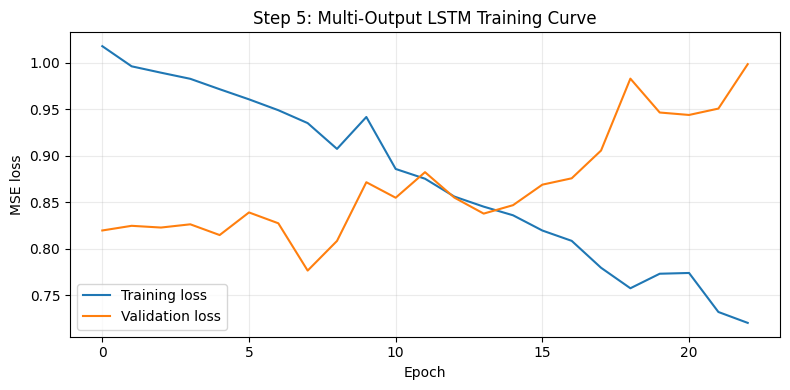

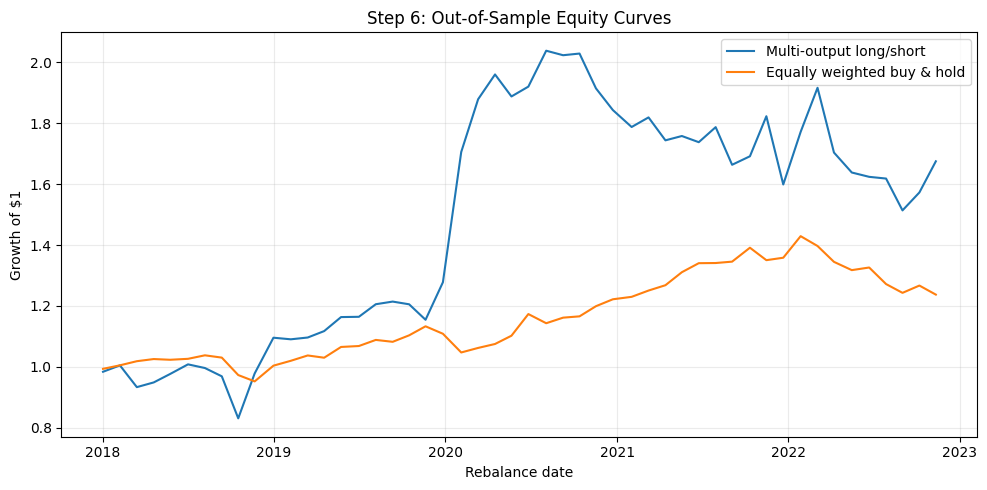

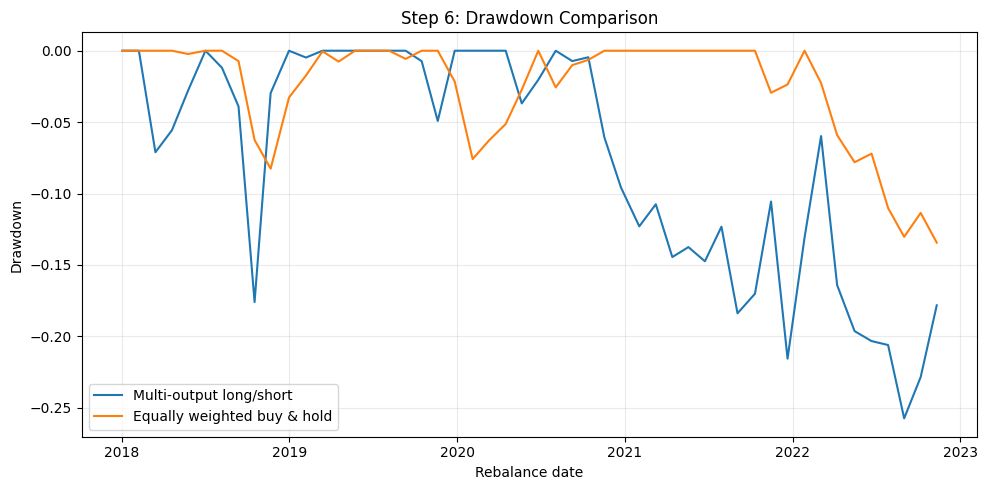

In [47]:
# Step 5 training curve
plt.figure(figsize=(8, 4))
plt.plot(hist_56.history["loss"], label="Training loss")
plt.plot(hist_56.history["val_loss"], label="Validation loss")
plt.title("Step 5: Multi-Output LSTM Training Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Step 6 equity curves
plt.figure(figsize=(10, 5))
plt.plot(bt_6.index, bt_6["strategy_equity"], label="Multi-output long/short")
plt.plot(bt_6.index, bt_6["ew_bh_equity"], label="Equally weighted buy & hold")
plt.title("Step 6: Out-of-Sample Equity Curves")
plt.xlabel("Rebalance date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Step 6 drawdown
strategy_dd = bt_6["strategy_equity"] / bt_6["strategy_equity"].cummax() - 1
benchmark_dd = bt_6["ew_bh_equity"] / bt_6["ew_bh_equity"].cummax() - 1

plt.figure(figsize=(10, 5))
plt.plot(bt_6.index, strategy_dd, label="Multi-output long/short")
plt.plot(bt_6.index, benchmark_dd, label="Equally weighted buy & hold")
plt.title("Step 6: Drawdown Comparison")
plt.xlabel("Rebalance date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Part III — Steps 7–8
The following cells preserve the completed Step 7 discussion and Step 8 reproducibility/submission checks.  
The duplicate Step 7–8 installation cells are omitted because the master notebook already has a common setup at the top.

## 1. Completed Results Imported for Step 7

The tables below reproduce the completed values already reported in Steps 1–6. They are entered here so that the Step 7 comparison is transparent and reproducible without retraining the earlier models.

In [48]:
asset_stats = pd.DataFrame({'ETF': ['SPY', 'TLT', 'SHY', 'GLD', 'DBO'], 'Ann_Return_pct': [11.94, 3.48, 0.7, 3.41, -4.33], 'Ann_Vol_pct': [17.67, 15.1, 1.1, 15.72, 30.58], 'Skew': [-0.73, -0.026, 0.096, -0.537, -0.728], 'Excess_Kurtosis': [11.559, 4.144, 8.731, 5.157, 5.985]})
display(asset_stats)

,ETF,Ann_Return_pct,Ann_Vol_pct,Skew,Excess_Kurtosis
0,SPY,11.94,17.67,-0.730,11.559
1,TLT,3.48,15.10,-0.026,4.144
2,SHY,0.70,1.10,0.096,8.731
3,GLD,3.41,15.72,-0.537,5.157
4,DBO,-4.33,30.58,-0.728,5.985


In [49]:
architecture_results = pd.DataFrame({'ETF': ['SPY', 'SPY', 'SPY', 'TLT', 'TLT', 'TLT', 'SHY', 'SHY', 'SHY', 'GLD', 'GLD', 'GLD', 'DBO', 'DBO', 'DBO'], 'Architecture': ['MLP', 'CNN-GAF', 'LSTM', 'MLP', 'CNN-GAF', 'LSTM', 'MLP', 'CNN-GAF', 'LSTM', 'MLP', 'CNN-GAF', 'LSTM', 'MLP', 'CNN-GAF', 'LSTM'], 'RMSE': [0.061, 0.06128, 0.06084, 0.04806, 0.04742, 0.04654, 0.00519, 0.00512, 0.00568, 0.04245, 0.04162, 0.04094, 0.11426, 0.11127, 0.11128], 'R2': [0.00912, 0.00018, 0.01452, -0.04756, -0.0199, 0.0177, -0.02499, 0.00235, -0.22589, -0.10022, -0.0577, -0.02341, -0.09309, -0.03677, -0.03689], 'Directional_Accuracy_pct': [66.56, 67.67, 67.36, 52.11, 47.1, 51.15, 58.06, 57.59, 53.06, 49.48, 47.18, 51.39, 46.86, 39.63, 39.87]})
display(architecture_results)

,ETF,Architecture,RMSE,R2,Directional_Accuracy_pct
0,SPY,MLP,0.06100,0.00912,66.56
1,SPY,CNN-GAF,0.06128,0.00018,67.67
2,SPY,LSTM,0.06084,0.01452,67.36
3,TLT,MLP,0.04806,-0.04756,52.11
4,TLT,CNN-GAF,0.04742,-0.01990,47.10
5,TLT,LSTM,0.04654,0.01770,51.15
6,SHY,MLP,0.00519,-0.02499,58.06
7,SHY,CNN-GAF,0.00512,0.00235,57.59
8,SHY,LSTM,0.00568,-0.22589,53.06
9,GLD,MLP,0.04245,-0.10022,49.48


In [50]:
single_multi_results = pd.DataFrame({'ETF': ['SPY', 'TLT', 'SHY', 'GLD', 'DBO'], 'Single_RMSE': [0.05439, 0.04149, 0.00294, 0.03956, 0.086], 'Multi_RMSE': [0.05444, 0.0416, 0.00295, 0.0395, 0.08606], 'Single_R2': [-0.0023, -0.0081, 0.0054, -0.0054, -0.0427], 'Multi_R2': [-0.0041, -0.0134, 0.0014, -0.0022, -0.0441], 'Single_Pred_Corr': [0.0698, 0.0164, 0.094, -0.0391, -0.0774], 'Multi_Pred_Corr': [-0.0074, -0.1487, 0.0525, -0.0065, -0.1043], 'Directional_Accuracy_pct': [58.47, 58.71, 57.82, 54.89, 48.86]})
display(single_multi_results)

,ETF,Single_RMSE,Multi_RMSE,Single_R2,Multi_R2,Single_Pred_Corr,Multi_Pred_Corr,Directional_Accuracy_pct
0,SPY,0.05439,0.05444,-0.0023,-0.0041,0.0698,-0.0074,58.47
1,TLT,0.04149,0.04160,-0.0081,-0.0134,0.0164,-0.1487,58.71
2,SHY,0.00294,0.00295,0.0054,0.0014,0.0940,0.0525,57.82
3,GLD,0.03956,0.03950,-0.0054,-0.0022,-0.0391,-0.0065,54.89
4,DBO,0.08600,0.08606,-0.0427,-0.0441,-0.0774,-0.1043,48.86


In [51]:
backtest_results = pd.DataFrame({'Metric': ['Annualised return', 'Annualised volatility', 'Sharpe ratio', 'Maximum drawdown', 'Block hit rate (>0)', 'Total return (2018-2022)', 'Number of 25-day blocks'], 'Multi-output long/short': ['4.17%', '17.61%', '0.24', '-21.87%', '56.0%', '22.97%', '50'], 'Equally-weighted buy & hold': ['6.36%', '7.55%', '0.84', '-7.61%', '60.0%', '37.10%', '50']})
display(backtest_results)

,Metric,Multi-output long/short,Equally-weighted buy & hold
0,Annualised return,4.17%,6.36%
1,Annualised volatility,17.61%,7.55%
2,Sharpe ratio,0.24,0.84
3,Maximum drawdown,-21.87%,-7.61%
4,Block hit rate (>0),56.0%,60.0%
5,Total return (2018-2022),22.97%,37.10%
6,Number of 25-day blocks,50,50


# Step 7 — Group Discussion

## 7.1 Comparative Predictability: MLP vs CNN-GAF vs LSTM

Across the five ETFs, no architecture dominates every evaluation metric. The LSTM records the lowest test RMSE for SPY (0.06084), TLT (0.04654) and GLD (0.04094), while the CNN-GAF records the lowest RMSE for SHY (0.00512) and, by a very small margin, DBO (0.11127 versus 0.11128 for the LSTM). The R-squared comparison gives a similar pattern: the LSTM has the highest test R-squared for SPY (0.01452), TLT (0.01770) and GLD (-0.02341), whereas the CNN-GAF is strongest for SHY (0.00235) and DBO (-0.03677). Directional accuracy does not follow the same ranking. The CNN-GAF is best for SPY at 67.67%, the MLP is best for TLT at 52.11%, SHY at 58.06% and DBO at 46.86%, and the LSTM is best for GLD at 51.39%. Therefore, a reduction in squared prediction error does not necessarily imply better prediction of the sign of future returns.

In [52]:
best_rows = []
for etf in ["SPY", "TLT", "SHY", "GLD", "DBO"]:
    d = architecture_results[architecture_results["ETF"] == etf]
    best_rows.append({
        "ETF": etf,
        "Lowest RMSE": d.loc[d["RMSE"].idxmin(), "Architecture"],
        "Highest R2": d.loc[d["R2"].idxmax(), "Architecture"],
        "Highest Directional Accuracy": d.loc[d["Directional_Accuracy_pct"].idxmax(), "Architecture"],
    })
best_architecture = pd.DataFrame(best_rows)
display(best_architecture)

,ETF,Lowest RMSE,Highest R2,Highest Directional Accuracy
0,SPY,LSTM,LSTM,CNN-GAF
1,TLT,LSTM,LSTM,MLP
2,SHY,CNN-GAF,CNN-GAF,MLP
3,GLD,LSTM,LSTM,LSTM
4,DBO,CNN-GAF,CNN-GAF,MLP


The differences are consistent with how the architectures process the input. The MLP uses the 60 lags as a fixed vector and can learn nonlinear combinations of those lagged values, but it has no explicit recurrent state or image-based representation. Its relatively stronger training fit in Step 2 did not generalize consistently to validation and test data. The CNN-GAF converts each 60-day return window into a two-dimensional representation of relationships within the sequence. This improved RMSE over the MLP for four of the five ETFs, but the improvement was not accompanied by consistently better directional accuracy. The LSTM processes the observations as an ordered sequence and retains a recurrent state, and it produced the lowest RMSE for three ETFs and positive test R-squared for both SPY and TLT. This provides the strongest evidence in the project that sequential treatment can help for some asset classes, although the advantage is small and is not universal.

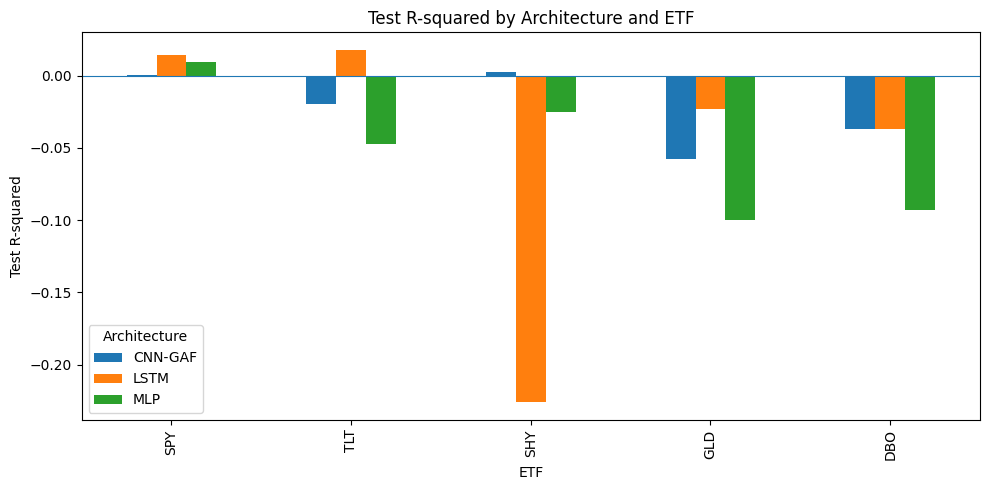

In [53]:
r2_pivot = architecture_results.pivot(
    index="ETF", columns="Architecture", values="R2"
).loc[["SPY","TLT","SHY","GLD","DBO"]]

ax = r2_pivot.plot(kind="bar", figsize=(10, 5))
ax.axhline(0, linewidth=0.8)
ax.set_title("Test R-squared by Architecture and ETF")
ax.set_xlabel("ETF")
ax.set_ylabel("Test R-squared")
ax.legend(title="Architecture")
plt.tight_layout()
plt.show()

## 7.2 Which Architecture Appears Better Suited to Which Asset Classes?

The asset-level results also reflect the statistical differences identified in Step 1. SPY has annualized volatility of 17.67%, negative skewness (-0.730) and high excess kurtosis (11.559). The LSTM gives the lowest SPY RMSE, while the CNN-GAF gives the highest directional accuracy, suggesting that both sequential and transformed temporal structure contain limited information, but neither model captures the magnitude of large tail events well. TLT is less skewed (-0.026) and has 15.10% annualized volatility. The LSTM is clearly the strongest TLT model on RMSE and R-squared, which is consistent with some benefit from modeling the ordered sequence of bond returns, although its 51.15% directional accuracy remains only slightly above chance.

SHY is the lowest-volatility asset at 1.10% annualized volatility. Its return movements are small and concentrated close to zero, so even very low absolute RMSE does not imply strong economic predictability. The CNN-GAF has the best SHY RMSE and the only positive R-squared among the three architectures, while the LSTM performs poorly out of sample. GLD has 15.72% annualized volatility and negative skewness (-0.537); the LSTM improves on both the MLP and CNN-GAF in RMSE and directional accuracy, but its R-squared remains negative, so the improvement is relative rather than strong in absolute terms. DBO is the most volatile asset at 30.58% annualized volatility, with negative skewness (-0.728), excess kurtosis of 5.985 and the largest rolling-volatility spike during the 2020 stress period. All three architectures remain weak for DBO. The CNN-GAF and LSTM have almost identical RMSE, and all test R-squared values are negative. This indicates that the large and irregular oil-return shocks are not reliably forecast from the historical return window used in this project.

## 7.3 Multi-Output versus Single-Output Predictability

For the single-output versus multi-output question, the paired Step 5 comparison is the appropriate basis because the single-output replica and the multi-output model were evaluated in the same Step 5 pipeline. The multi-output architecture does not materially improve headline prediction error. It is slightly worse for SPY, TLT, SHY and DBO and only marginally better for GLD, where RMSE falls from 0.03956 to 0.03950. R-squared and prediction correlations also remain very small or negative. SHY is the only ETF with a positive R-squared in both versions, and even there the value falls from 0.0054 for the single-output replica to 0.0014 for the multi-output model. Thus, adding cross-asset inputs does not produce a meaningful out-of-sample accuracy gain.

In [54]:
single_multi_view = single_multi_results[[
    "ETF","Single_RMSE","Multi_RMSE","Single_R2","Multi_R2",
    "Single_Pred_Corr","Multi_Pred_Corr","Directional_Accuracy_pct"
]].copy()
display(single_multi_view)

,ETF,Single_RMSE,Multi_RMSE,Single_R2,Multi_R2,Single_Pred_Corr,Multi_Pred_Corr,Directional_Accuracy_pct
0,SPY,0.05439,0.05444,-0.0023,-0.0041,0.0698,-0.0074,58.47
1,TLT,0.04149,0.04160,-0.0081,-0.0134,0.0164,-0.1487,58.71
2,SHY,0.00294,0.00295,0.0054,0.0014,0.0940,0.0525,57.82
3,GLD,0.03956,0.03950,-0.0054,-0.0022,-0.0391,-0.0065,54.89
4,DBO,0.08600,0.08606,-0.0427,-0.0441,-0.0774,-0.1043,48.86


However, the prediction-correlation matrices show that the multi-output model is not simply reproducing five independent models. The independent single-output predictions are mostly close to uncorrelated across ETFs, while the multi-output predictions contain much stronger cross-asset relationships, including TLT-GLD at 0.451 and GLD-DBO at -0.773. This demonstrates that the shared representation is using joint information. The problem is that the learned dependence does not consistently match the realized 25-day return dependence. For example, the multi-output model predicts SPY-TLT correlation of +0.316 while the realized correlation is -0.303, and it predicts GLD-DBO correlation of -0.773 while the realized correlation is only 0.016. Therefore, the multi-output architecture captures cross-asset structure that the single-output models cannot capture, but in this sample the additional structure does not translate into more accurate or economically useful forecasts. The two architectures are also not using the same information: the single-output models observe only one ETF's history, whereas the multi-output model observes all five histories jointly.

In [55]:
multi_prediction_corr = pd.DataFrame(
    [[1.0, 0.316, -0.13, -0.18, 0.194], [0.316, 1.0, -0.392, 0.451, -0.438], [-0.13, -0.392, 1.0, -0.207, 0.096], [-0.18, 0.451, -0.207, 1.0, -0.773], [0.194, -0.438, 0.096, -0.773, 1.0]],
    index=['SPY', 'TLT', 'SHY', 'GLD', 'DBO'],
    columns=['SPY', 'TLT', 'SHY', 'GLD', 'DBO']
)
single_prediction_corr = pd.DataFrame(
    [[1.0, 0.023, -0.061, 0.017, 0.028], [0.023, 1.0, -0.054, -0.034, -0.007], [-0.061, -0.054, 1.0, -0.058, 0.16], [0.017, -0.034, -0.058, 1.0, -0.058], [0.028, -0.007, 0.16, -0.058, 1.0]],
    index=['SPY', 'TLT', 'SHY', 'GLD', 'DBO'],
    columns=['SPY', 'TLT', 'SHY', 'GLD', 'DBO']
)
realized_25d_corr = pd.DataFrame(
    [[1.0, -0.303, -0.025, -0.063, 0.251], [-0.303, 1.0, 0.493, 0.276, -0.366], [-0.025, 0.493, 1.0, 0.073, -0.269], [-0.063, 0.276, 0.073, 1.0, 0.016], [0.251, -0.366, -0.269, 0.016, 1.0]],
    index=['SPY', 'TLT', 'SHY', 'GLD', 'DBO'],
    columns=['SPY', 'TLT', 'SHY', 'GLD', 'DBO']
)

print("Multi-output prediction correlations")
display(multi_prediction_corr.round(3))
print("Single-output prediction correlations")
display(single_prediction_corr.round(3))
print("Realized 25-day return correlations")
display(realized_25d_corr.round(3))

Multi-output prediction correlations


,SPY,TLT,SHY,GLD,DBO
SPY,1.000,0.316,-0.130,-0.180,0.194
TLT,0.316,1.000,-0.392,0.451,-0.438
SHY,-0.130,-0.392,1.000,-0.207,0.096
GLD,-0.180,0.451,-0.207,1.000,-0.773
DBO,0.194,-0.438,0.096,-0.773,1.000


Single-output prediction correlations


,SPY,TLT,SHY,GLD,DBO
SPY,1.000,0.023,-0.061,0.017,0.028
TLT,0.023,1.000,-0.054,-0.034,-0.007
SHY,-0.061,-0.054,1.000,-0.058,0.160
GLD,0.017,-0.034,-0.058,1.000,-0.058
DBO,0.028,-0.007,0.160,-0.058,1.000


Realized 25-day return correlations


,SPY,TLT,SHY,GLD,DBO
SPY,1.000,-0.303,-0.025,-0.063,0.251
TLT,-0.303,1.000,0.493,0.276,-0.366
SHY,-0.025,0.493,1.000,0.073,-0.269
GLD,-0.063,0.276,0.073,1.000,0.016
DBO,0.251,-0.366,-0.269,0.016,1.000


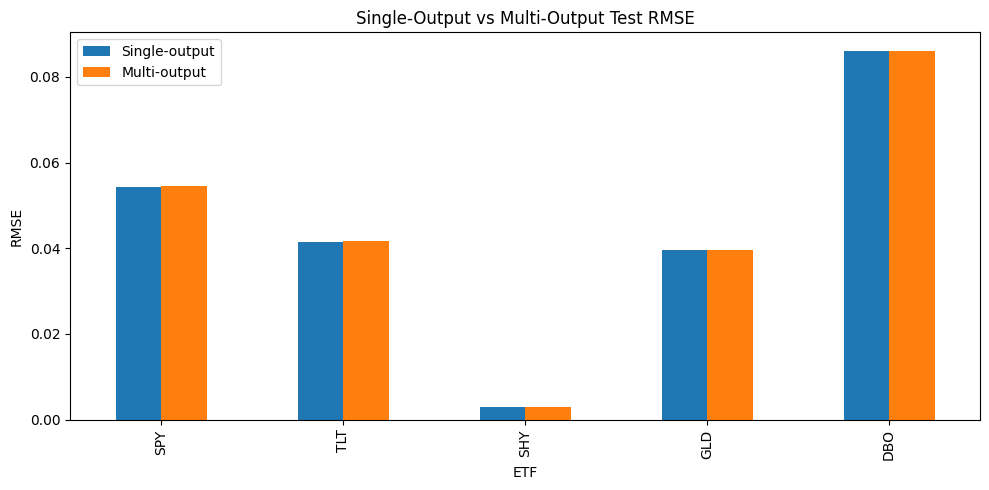

In [56]:
rmse_compare = single_multi_results.set_index("ETF")[["Single_RMSE","Multi_RMSE"]]
ax = rmse_compare.plot(kind="bar", figsize=(10, 5))
ax.set_title("Single-Output vs Multi-Output Test RMSE")
ax.set_xlabel("ETF")
ax.set_ylabel("RMSE")
ax.legend(["Single-output", "Multi-output"])
plt.tight_layout()
plt.show()

## 7.4 Backtesting Performance and Practical Value

The Step 6 backtest provides the clearest test of practical value. The multi-output long/short strategy produces a 4.17% annualized return with 17.61% annualized volatility, a Sharpe ratio of 0.24, maximum drawdown of -21.87%, a 56.0% positive-block hit rate and 22.97% total return over the test period. The equally weighted buy-and-hold benchmark produces a higher 6.36% annualized return with much lower 7.55% volatility, a Sharpe ratio of 0.84, maximum drawdown of only -7.61%, a 60.0% hit rate and 37.10% total return. The benchmark therefore outperforms the model-driven strategy on return, risk-adjusted return and drawdown.

In [57]:
display(backtest_results)

,Metric,Multi-output long/short,Equally-weighted buy & hold
0,Annualised return,4.17%,6.36%
1,Annualised volatility,17.61%,7.55%
2,Sharpe ratio,0.24,0.84
3,Maximum drawdown,-21.87%,-7.61%
4,Block hit rate (>0),56.0%,60.0%
5,Total return (2018-2022),22.97%,37.10%
6,Number of 25-day blocks,50,50


These results imply that multi-asset prediction has limited practical value in the current setup. The models are not accurate enough to rank the five future returns consistently, and taking both long and short positions magnifies the consequences of ranking errors. The backtest does not reject the value of diversification; instead, it shows that the passive diversified portfolio is more effective than the active model-based allocation produced by the current signals. The practical recommendation is therefore to retain a diversified passive allocation as the core portfolio and treat model-based forecasts, if used at all, as a small overlay until materially stronger out-of-sample predictive performance is demonstrated.

## 7.5 Overall Step 7 Conclusion

Overall, the project shows that architecture matters, but the gain from greater model complexity is modest relative to the difficulty of forecasting financial returns. The MLP is a useful nonlinear baseline; the CNN-GAF improves error measures for several assets; and the LSTM gives the strongest overall error-based results for SPY, TLT and GLD. Nevertheless, no architecture is uniformly superior, and DBO remains particularly difficult. The multi-output model clearly learns a different cross-asset representation from the single-output models, but this extra information does not improve forecast accuracy enough to add value in the allocation backtest. The final investment result is therefore consistent with the predictive evidence: weak out-of-sample signals are not sufficient to justify replacing a simple diversified benchmark.

# Step 8 — Reproducibility and Submission Preparation

## 8.1 Submission Structure

## 8.2 Reproducibility Checks

Before submission, run each notebook from a clean runtime in chronological order and confirm that all cells execute without error, all tables and figures are regenerated, the test period remains 2018-2022, and the results in the final PDF match the notebook outputs. The submitting group member should then verify that the final PDF is uploaded separately from the ZIP folder, that the ZIP contains the complete reproducibility files, and that only the final versions are submitted.

In [58]:
# Results consistency checks used in Step 7
assert set(architecture_results["ETF"]) == {"SPY","TLT","SHY","GLD","DBO"}
assert len(architecture_results) == 15
assert len(single_multi_results) == 5
assert len(backtest_results) == 7

# Confirm the architecture winners reported in the discussion.
expected_rmse_winners = {
    "SPY": "LSTM",
    "TLT": "LSTM",
    "SHY": "CNN-GAF",
    "GLD": "LSTM",
    "DBO": "CNN-GAF",
}
calculated = dict(zip(best_architecture["ETF"], best_architecture["Lowest RMSE"]))
assert calculated == expected_rmse_winners

print("Step 7 result tables passed consistency checks.")

Step 7 result tables passed consistency checks.


## References Used in the Step 7–8 Discussion

- Caruana, Rich. “Multitask Learning.” *Machine Learning*, vol. 28, no. 1, 1997, pp. 41–75.
- Goodfellow, Ian, Yoshua Bengio, and Aaron Courville. *Deep Learning*. MIT Press, 2016.
- Hochreiter, Sepp, and Jürgen Schmidhuber. “Long Short-Term Memory.” *Neural Computation*, vol. 9, no. 8, 1997, pp. 1735–1780.
- WorldQuant University. *MScFE 642 Deep Learning for Finance: Group Work Project 1*. Revised 15 May 2026.